##    MP307 Practical 3 Discrete Population Models

**Name:** Cian Mac Liatháin

**ID:** 11476078

In [1]:
%matplotlib notebook
import numpy as np
import matplotlib.pyplot as plt

## Q.1(*) Geometric Population Model
Consider the geometric population model $P_{n+1}=(1+r)P_{n}$ for $n=0,1,\ldots$ with solution $
P_{n}=P_{0}e^{sn}$ for $s=\log (1+r)$ as a model of 
 1. Sweden's population with 11 samples from 1750 to 1960 
 2. The US population with 19 samples from 1790 to 1990.

 ### Population of Sweden
 The data (in millions) are given in the lists `Year` and `Pop` below.

In [2]:
Year = [1750, 1770, 1790, 1810, 1830, 1850, 1870, 1890, 1910, 1930, 1960]
Pop= [1.76, 2.03, 2.158, 2.378, 2.888, 3.48, 4.17, 4.785, 5.522, 6.14, 7.49]

<IPython.core.display.Javascript object>


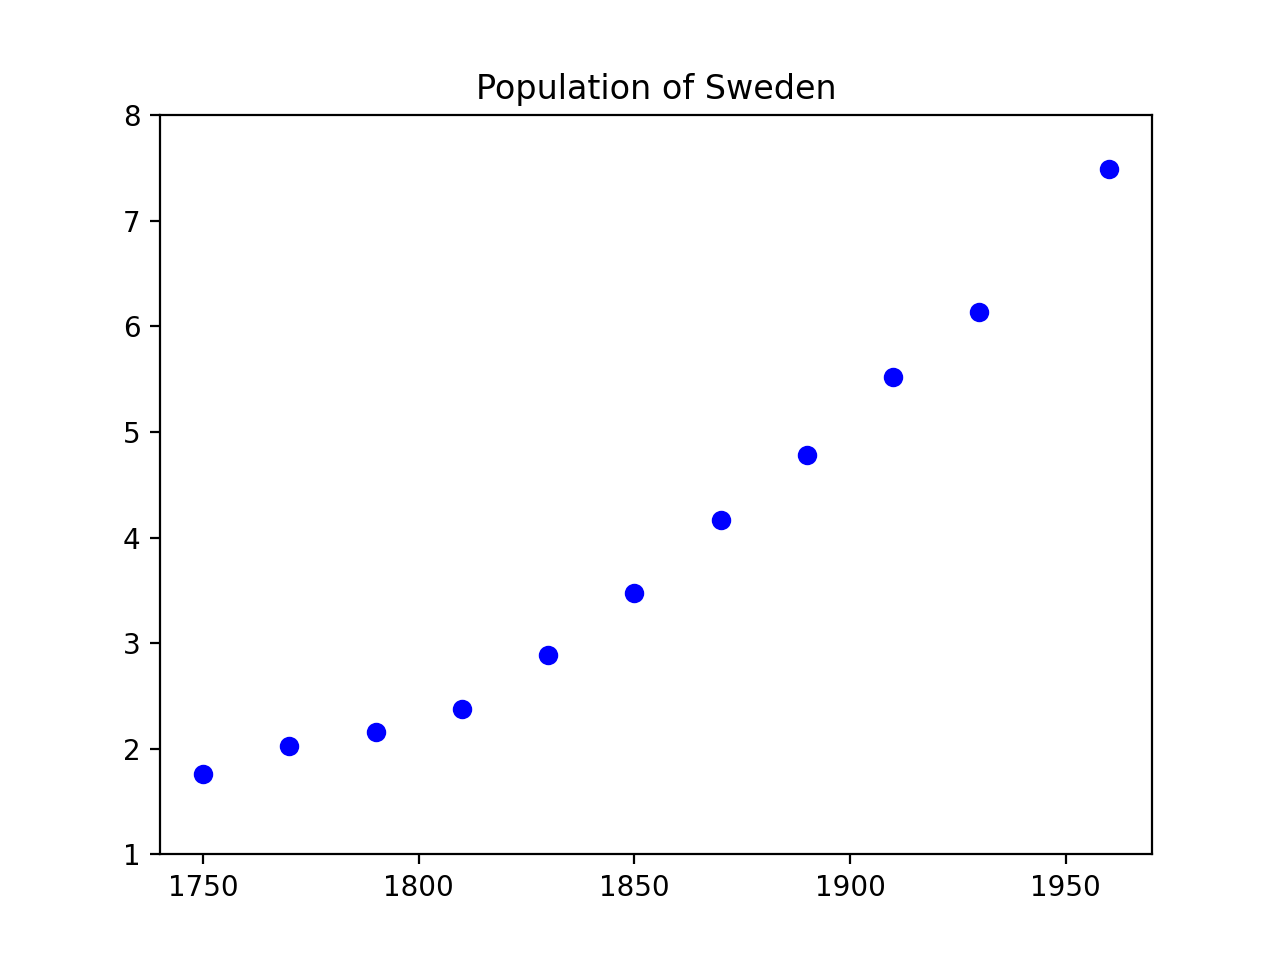

In [3]:
plt.figure(1)
plt.plot(Year,Pop,'bo')
plt.axis([1740,1970,1,8])
plt.title('Population of Sweden')
plt.show()

Look at t vs log(P):

<IPython.core.display.Javascript object>


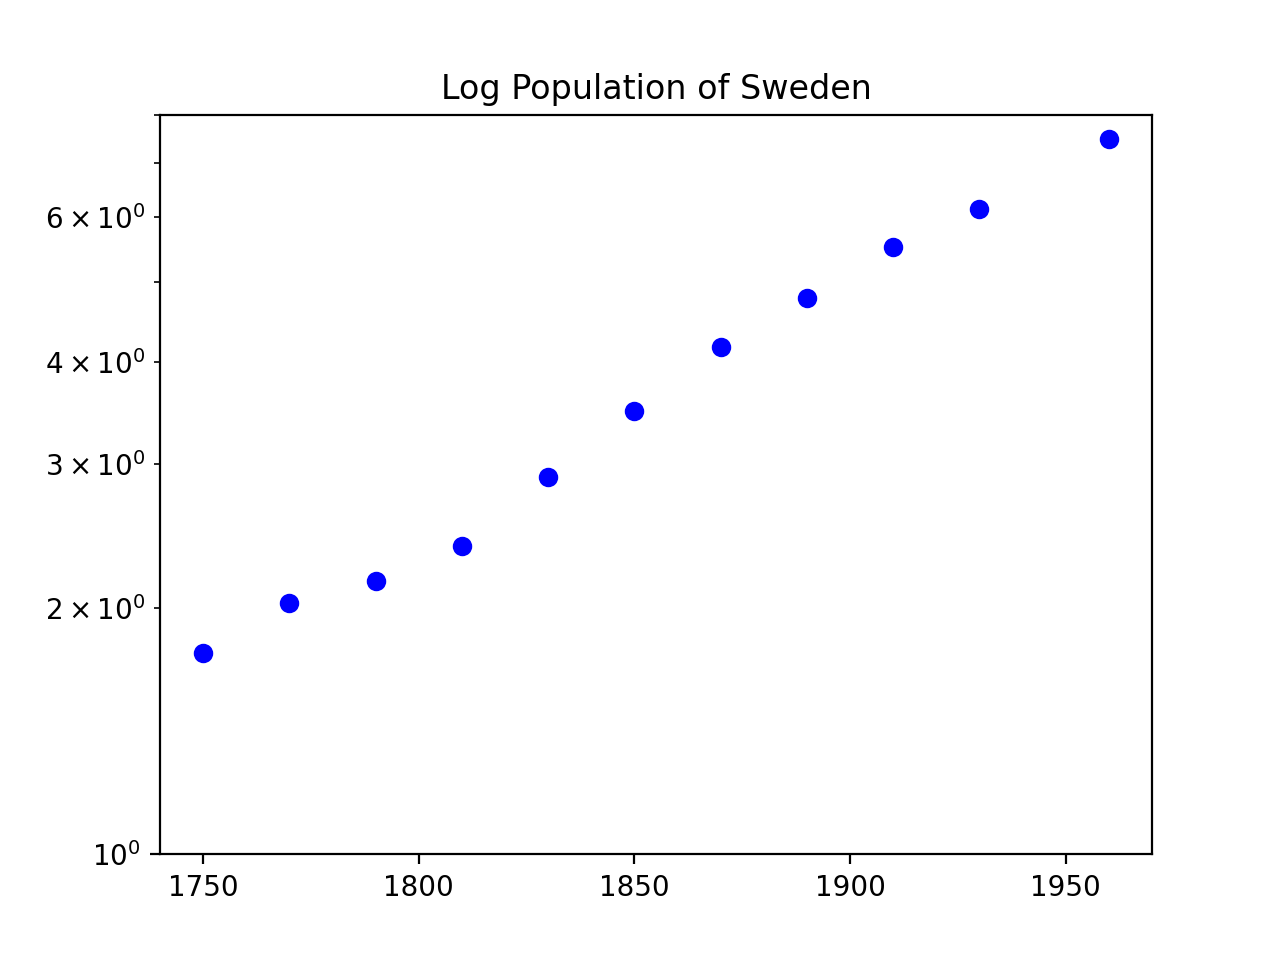

In [4]:
plt.figure(2) # new figure
plt.plot(Year,Pop,'bo')
plt.yscale("log")
plt.axis([1740,1970,1,8])
plt.title('Log Population of Sweden')
plt.show()

The log plot suggest a linear relationship to between $\log P$ and $t$ of the form $\log P(t)=st+b$ for some $s,b$. Thus $P(t)=P_{0}e^{st}$ with $P_{0}=\exp(b)$. 

In [5]:
log_Pop=np.log(Pop) # take log of each entry in S_Pop

In [6]:
print(log_Pop)

[0.56531381 0.70803579 0.76918187 0.8662598  1.06056422 1.24703229
 1.42791604 1.56548602 1.70874011 1.81482474 2.0135688 ]


Use a least squares approximation to find a line as explained in the notes for matching data $x_{i}$ to $y_{i}$.  

In [7]:
N=len(Year) # no of elements in S_Year
sumx=0; sumy=0; sumxx=0; sumxy=0; 
for i in range(N):
    sumx=sumx+Year[i]
    sumy=sumy+log_Pop[i]
    sumxx=sumxx+Year[i]**2
    sumxy=sumxy+log_Pop[i]*Year[i]
Xbar=sumx/N
Ybar=sumy/N
XXbar=sumxx/N
XYbar=sumxy/N

In [8]:
s=(XYbar-Xbar*Ybar)/(XXbar-Xbar**2)
b=(XXbar*Ybar-Xbar*XYbar)/(XXbar-Xbar**2)

P_0=np.exp(b)
print(s,P_0)

0.0072182711579564076 5.500654960458621e-06


Plot population $P(t)=P_{0}e^{st}$ vs $t$.

In [9]:
t=np.arange(1740.0,1970.,5.)
P_LS=P_0*np.exp(s*t) # least squares approximation

<IPython.core.display.Javascript object>


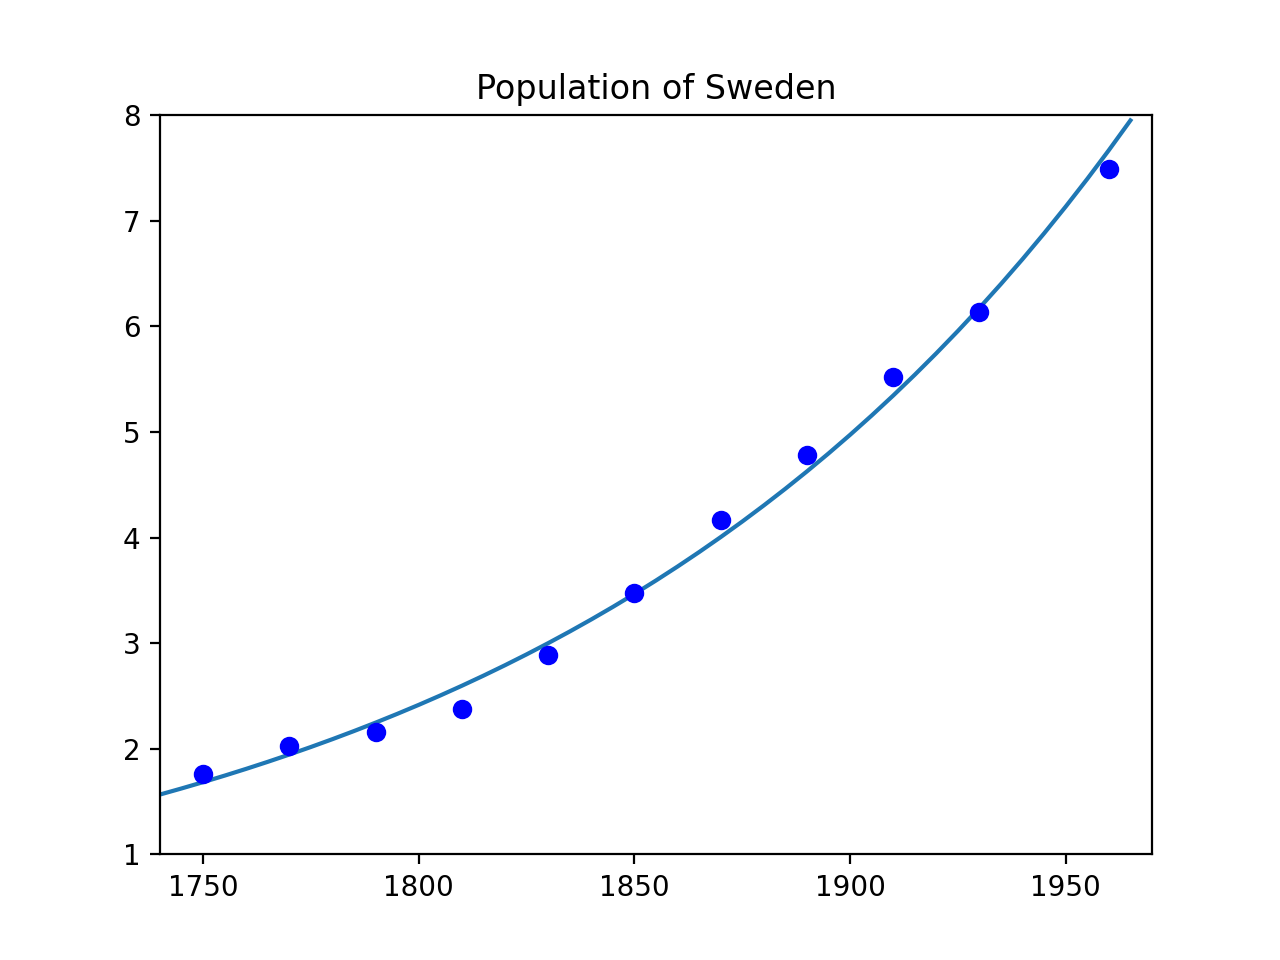

In [10]:
plt.figure(3)
plt.plot(t,P_LS)
plt.plot(Year,Pop,'bo')
plt.axis([1740,1970,1,8])
plt.title('Population of Sweden')
plt.show()

###  Repeat this analysis for the US population as follows:

In [11]:
Year = [1790, 1820, 1830, 1840, 1850, 1860, 1870, 1880, 1890, 1900, 1910, 1920, 1930, 1940, 1950, 1960, 1970, 1980, 1990]
Pop= [3.79, 9.6, 12.9, 17.1, 23.2, 31.4, 38.6, 50.2, 62.9, 76.0, 92.0, 106.5, 123.2, 132.0, 151.3, 179.3, 203.3, 226.54, 248.7]

<IPython.core.display.Javascript object>


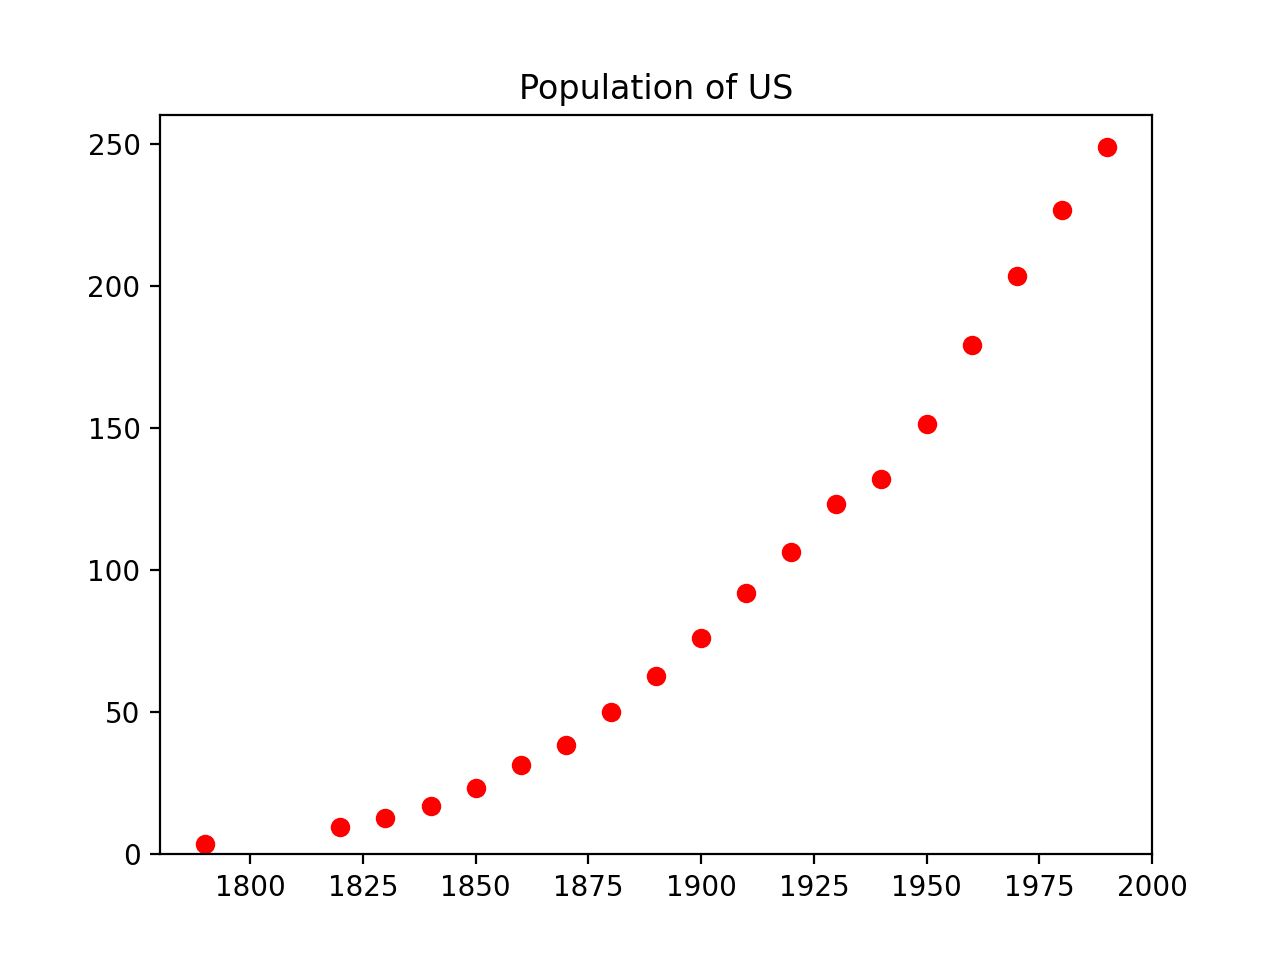

In [12]:
plt.figure(4)
plt.plot(Year,Pop,'ro')
plt.axis([1780,2000,0,260])
plt.title('Population of US')
plt.show()

Look at t vs log(P):

<IPython.core.display.Javascript object>


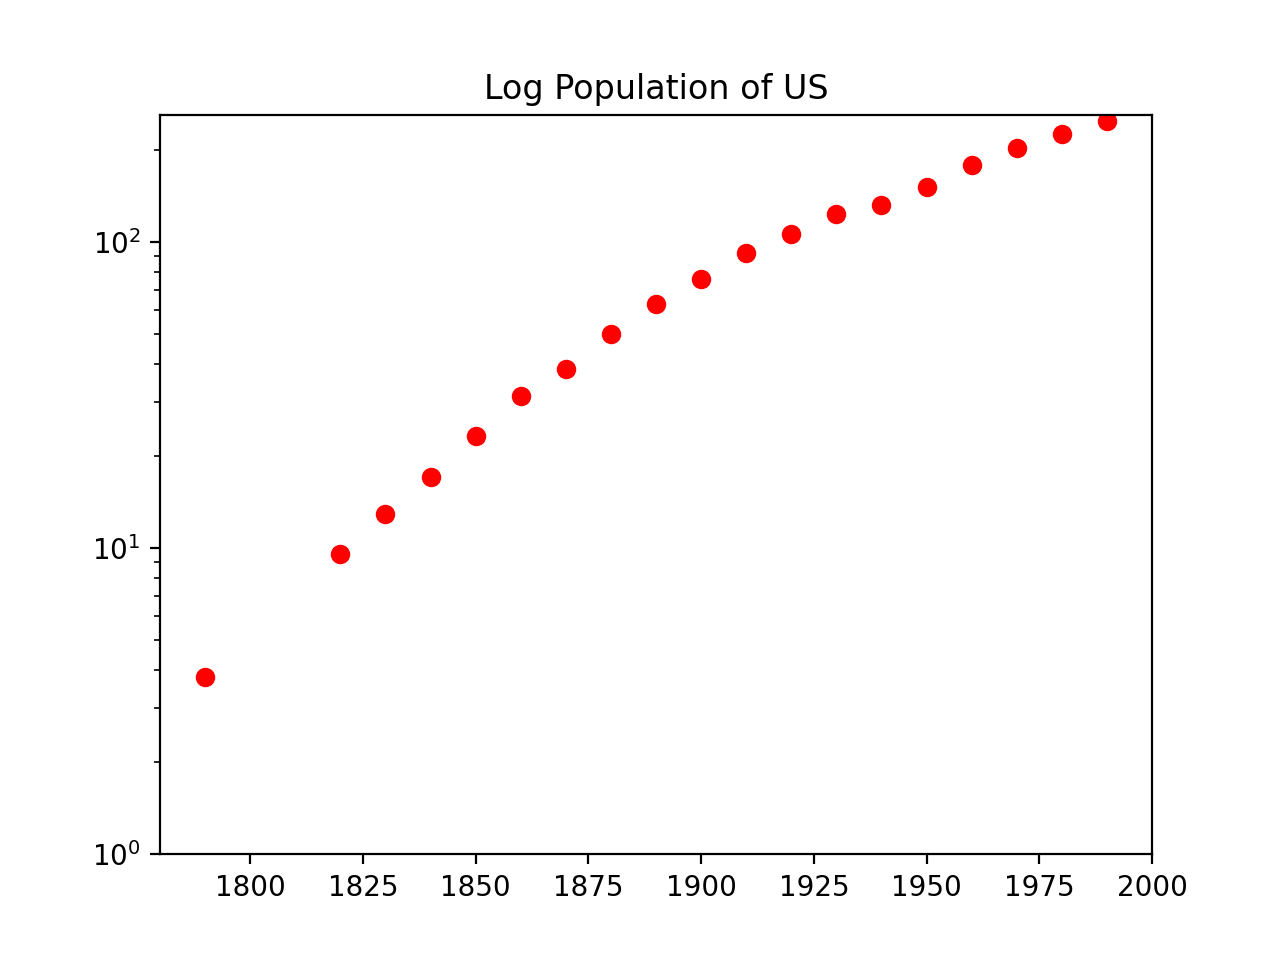

In [15]:
plt.figure(5) # new figure
plt.plot(Year,Pop,'ro')
plt.yscale("log")
plt.axis([1780,2000,1,260])
plt.title('Log Population of US')
plt.show()

In [16]:
log_Pop=np.log(Pop) 

In [17]:
print(log_Pop)

[1.33236602 2.2617631  2.55722731 2.83907846 3.14415228 3.44680789
 3.65325228 3.91601503 4.14154616 4.33073334 4.52178858 4.66814499
 4.81380905 4.88280192 5.01926462 5.18906038 5.31468272 5.42292153
 5.51624735]


In [18]:
N=len(Year) # no of elements in US_Year
sumx=0; sumy=0; sumxx=0; sumxy=0; 
for i in range(N):
    sumx=sumx+Year[i]
    sumy=sumy+log_Pop[i]
    sumxx=sumxx+Year[i]**2
    sumxy=sumxy+log_Pop[i]*Year[i]
Xbar=sumx/N
Ybar=sumy/N
XXbar=sumxx/N
XYbar=sumxy/N

In [20]:
s=(XYbar-Xbar*Ybar)/(XXbar-Xbar**2)
b=(XXbar*Ybar-Xbar*XYbar)/(XXbar-Xbar**2)

P_0=np.exp(b)
print(s,P_0)

0.020051106626461583 1.6718326017274779e-15


In [21]:
t=np.arange(1780.0,2000.0,5.)
P_LS=P_0*np.exp(s*t) # least squares approximation

<IPython.core.display.Javascript object>


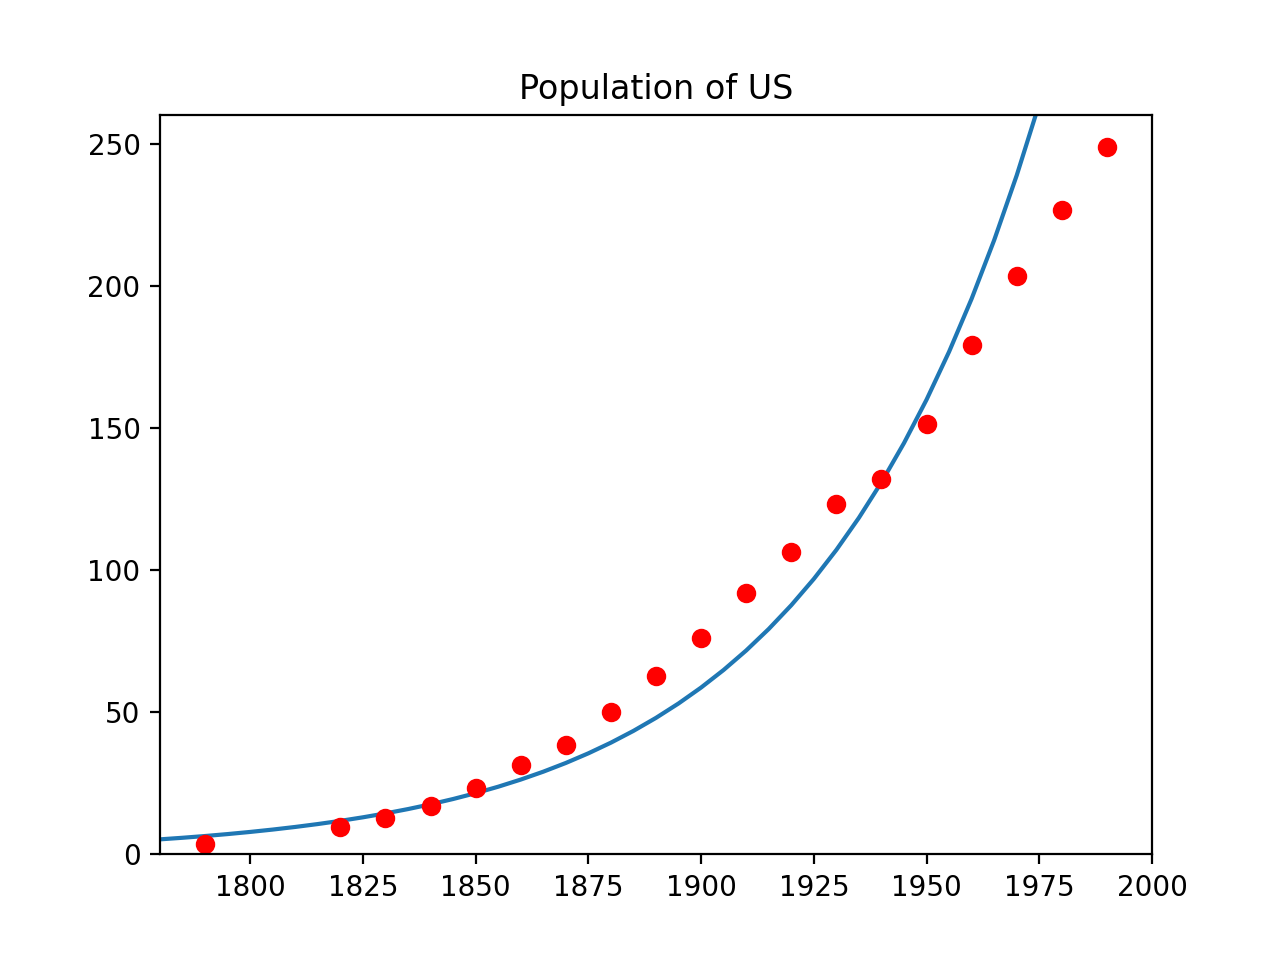

In [22]:
plt.figure(6)
plt.plot(t,P_LS)
plt.plot(Year,Pop,'ro')
plt.axis([1780,2000,0,260])
plt.title('Population of US')
plt.show()

## Q.2 (*) Discrete Verhulst Model
The general discrete Verhulst model of population growth is as follows 
$$
P_{n+1}=\dfrac{1+r}{1+\dfrac{rP_{n}}{K}}P_{n} 
$$
where $P_{n}\rightarrow K$ as $n\rightarrow \infty $. 

For the choice of
parameters $P_{0}=3.79$, $r=0.35$ and $K=300$ compare the Verhulst model to
the US population from 1790 to 1990. Explain what you see.

In [23]:
print(Year)

[1790, 1820, 1830, 1840, 1850, 1860, 1870, 1880, 1890, 1900, 1910, 1920, 1930, 1940, 1950, 1960, 1970, 1980, 1990]


In [24]:
P_0=3.79
r=0.35
K=300.0

In [25]:
# plot Verhulst pop PV from 1790 to 1990 with 10 year intervals
PV=[0]*20 # list for Verhulst P initialized with 20 zeros
YV=[0]*20 # list for years initialized with 20 zeros

PV[0]=P_0
YV[0]=1790
# choose 10 year intervals
for n in range(1,20):
    YV[n]=1790+10*n
    PV[n]=(1+r)*PV[n-1]/(1+r*PV[n-1]/K) 
    

In [26]:
print(PV)

[3.79, 5.093976135520772, 6.836240197791433, 9.15590034404303, 12.229827865107413, 16.278010802773355, 21.56575898309768, 28.39924806493404, 37.10945741970735, 48.0188229724253, 61.386423256309854, 77.33325731948169, 95.76020718123476, 116.28490230208658, 138.23136107104716, 160.69678033606021, 182.69000801767106, 203.3004004123143, 221.83893811890553, 237.9088727981478]


<IPython.core.display.Javascript object>


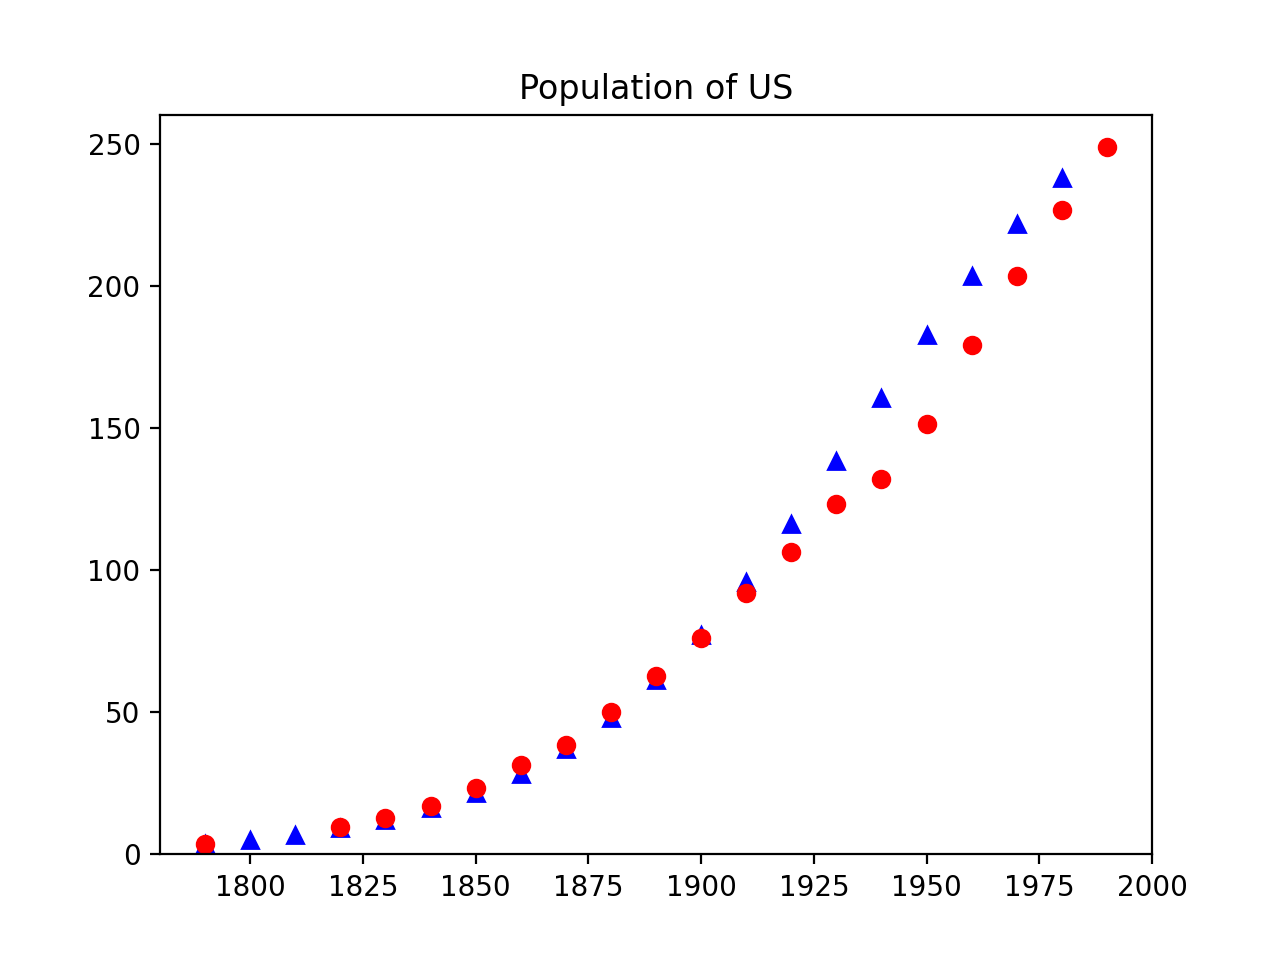

In [27]:
plt.figure(7)
plt.plot(YV,PV,'b^')
plt.plot(Year,Pop,'ro')
plt.axis([1780,2000,0,260])
plt.title('Population of US')
plt.show()

We can see that the Verhulst model provides a very accurate estimation of US population from 1790 until 1925. The higher estimation than the actual US population from 1925 to 1990 may be due to unexpected factors effecting the population size like the First and Second World Wars and the Great Depression.

## Q.3 (*) Cohort Model
Consider the human population divided into three age groups $0-14$, $15-39$ and $\geq 40$
with population size $P_{i}$ , $i=1,2,3$ and yearly birth rates of 0, 0.06
and 0 and death rates of 0.005, 0.01 and 0.015, respectively.

(a). Show that ${\bf P}(t+1)={\bf AP}(t)$ where 
$${\bf P}=
\begin{bmatrix}
P_{1} \\ 
P_{2} \\ 
P_{3}%
\end{bmatrix} ,\quad {\bf A}=
\begin{bmatrix}
0.\,92867 & 0.06 & 0 \\ 
0.06\,63 & 0.\,9504 & 0 \\ 
0 & 0.0\,396 & 0.985%
\end{bmatrix}.$$

(b). Find the largest eigenvalue of ${\bf A}$ and describe the long-term
behaviour of this system.

(c). Consider the growth of the population with the following initial
populations. How long does it take for the total population to double in
each case?

$\quad$ (i)  $P_{1}=200$, $P_{2}=P_{3}=400$.
    
$\quad$   (ii) $P_{1}=400$, $P_{2}=P_{3}=300$.
    
$\quad$   (iii) $P_{1}=200$, $P_{2}=500$ and $P_{3}=300$.

Explain what you see.

**(a)** 

$P_1(t+1) = b_1P_1(t) + \frac{14}{15}(1-d_1)P_1(t)+b_2P_2(t)+b_3P_3(t) = 0.92867P_1(t) + 0.06P_2(t) $

$P_2(t+1)=\frac{1}{15}(1-d_1)P_1(t)+\frac{24}{25}(1-d_2)P_2(t) = 0.0663P_1(t) + 0.9504P_2(t)$

$P_3(t+1)=\frac{1}{25}(1-d_2)P_2(t)+(1-d_3)P_3(t) = 0.0396P_2(t) + 0.985P_3(t)$


In [31]:
b=[0, 0.06 ,0]
d=[0.005, 0.01, 0.015]

In [32]:
A=np.mat([[b[0] + 14/15 - 14/15 * d[0], b[1], b[2]],
           [1/15*(1-d[0]), 24/25*(1-d[1]), 0],
           [0, 1/25*(1-d[1]), 1-d[2]]])
# recall Python indexing begins at 0

In [33]:
print(A)

[[0.92866667 0.06       0.        ]
 [0.06633333 0.9504     0.        ]
 [0.         0.0396     0.985     ]]


$P(t+1) = AP(t)$

Find eigenvalues and eigenvectors

In [34]:
X, V=np.linalg.eig(A)
print(X) # eigen values
print(V) # columns are right eigenvectors

[0.985      1.00354962 0.87551705]
[[ 0.          0.32180453  0.72790385]
 [ 0.          0.40162787 -0.64479684]
 [ 1.          0.85740124  0.23322312]]


**(b)** 
Can extract first, second, third eigenvalues/vectors as follows:

In [35]:
lambda0=X[0]
u0=V[:,0] # This is a 3 by 1 matrix
print(lambda0,u0)

0.985 [[0.]
 [0.]
 [1.]]


In [36]:
np.matmul(A,u0)/lambda0 # A u = lambda u

matrix([[0.],
        [0.],
        [1.]])

In [37]:
lambda1=X[1]
u1=V[:,1]
print(lambda1,u1)

1.0035496159842685 [[0.32180453]
 [0.40162787]
 [0.85740124]]


In [38]:
np.matmul(A,u1)/lambda1 # A u = lambda u

matrix([[0.32180453],
        [0.40162787],
        [0.85740124]])

In [39]:
lambda2=X[2]
u2=V[:,2]
print(lambda2,u2)

0.8755170506823979 [[ 0.72790385]
 [-0.64479684]
 [ 0.23322312]]


In [40]:
np.matmul(A,u2)/lambda2 # A u = lambda u

matrix([[ 0.72790385],
        [-0.64479684],
        [ 0.23322312]])

In [41]:
max(lambda0, lambda1, lambda2)

1.0035496159842685

We can see that the largest eigenvalue is lambda1 with a value of 1.0035496159842685.

As this is greater than 1, slow exponential growth will occur in this model.

(c) Initial poplulation $P_{1}=P_{2}=P_{3}=100$.

In [42]:
P0=[100,100,100] 

In [43]:
np.matmul(A,P0) # population after one year

matrix([[ 98.86666667, 101.67333333, 102.46      ]])

In [44]:
n=20 # 20 years
An=np.linalg.matrix_power(A,n) # matrix A^n
print(An)

[[0.48657128 0.47022728 0.        ]
 [0.51986238 0.65689805 0.        ]
 [0.24436408 0.51787528 0.73913643]]


In [62]:
Pn=np.matmul(An,P0) # population after n years
print(Pn)

[[ 95.67985614 117.67604324 150.13757869]]


In [64]:
Pn.sum()

363.49347806660535

Define lists P1, P2, P3 giving population at time 0,1,2,3, etc

<IPython.core.display.Javascript object>


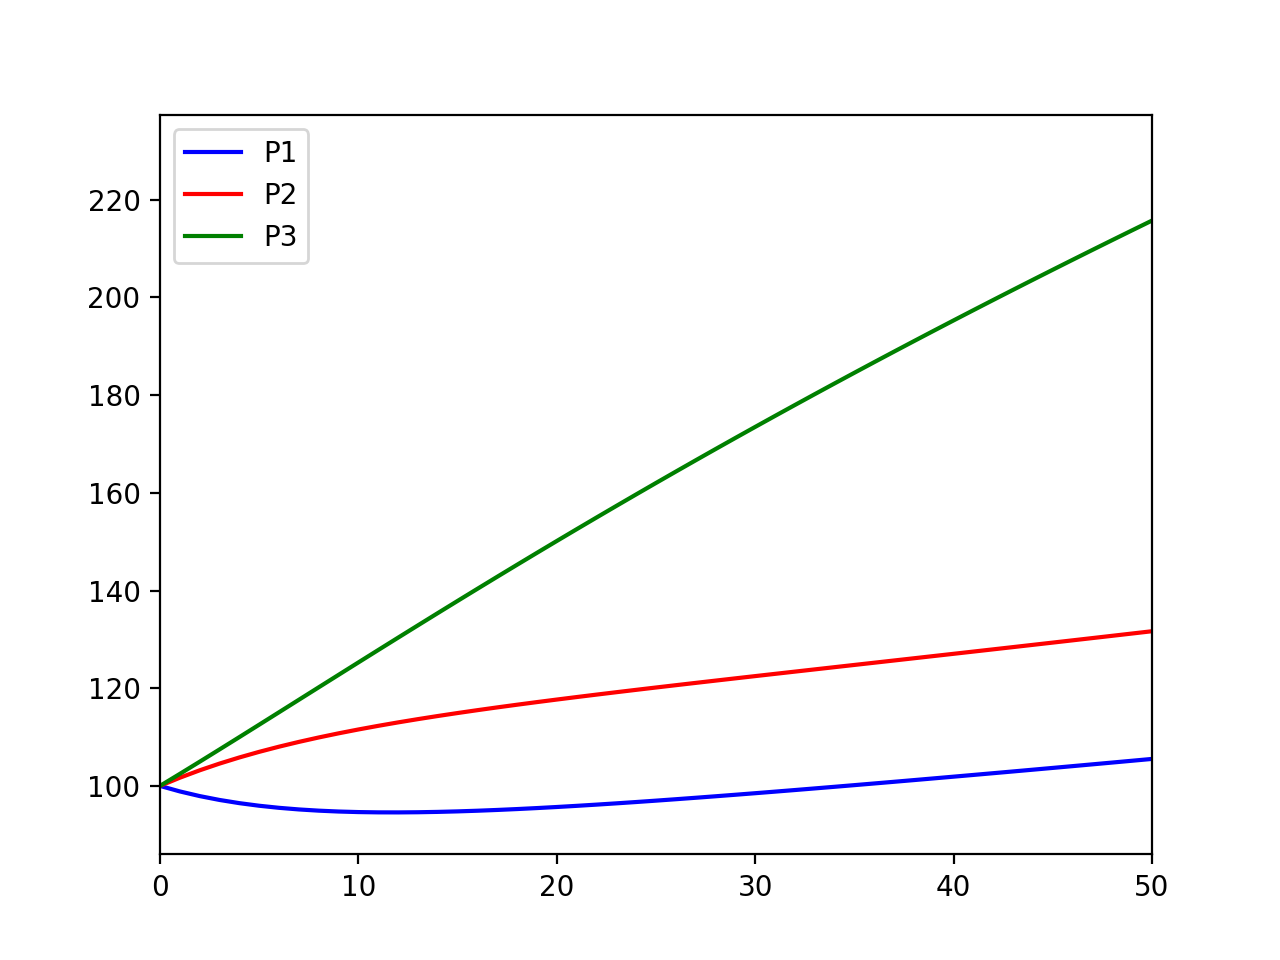

In [51]:
nit=50 # nit is no of time steps

#initialise list to zero

P1=[0]*(nit+1)
P2=[0]*(nit+1)
P3=[0]*(nit+1)

#Given initial population

P1[0],P2[0],P3[0]=100,100,100

# compute P1,P2,P3 
for n in range(1,nit+1):
    AP=np.matmul(A,[P1[n-1],P2[n-1],P3[n-1]]) # AP[n-1]
    P1[n],P2[n],P3[n]=AP[0,0],AP[0,1],AP[0,2]

# plotting 

t=np.arange(0,nit+1,1) #  time steps
plt.figure()
P1plot,=plt.plot(t,P1,'b-')
P2plot,=plt.plot(t,P2,'r-')
P3plot,=plt.plot(t,P3,'g-')
plt.legend((P1plot,P2plot,P3plot),('P1','P2','P3'))
Pmax=max(max(P1),max(P2),max(P3))
Pmin=min(min(P1),min(P1),min(P1))
plt.axis([0,nit,Pmin/1.1,Pmax*1.1])
plt.show()

Compare populations to eigenvector for largest eigenvalue

In [52]:
print(P2[50]/P1[50],u1[1,0]/u1[0,0]) # compare first and second cohorts to eigenvector entries

1.247744063179402 1.248049155293366


In [53]:
print(P3[50]/P1[50],u1[2,0]/u1[0,0]) # compare first and third cohorts to eigenvector entries

2.0444670328229053 2.664354161915348


**(c)**

**(i) $𝑃_1=200, 𝑃_2=𝑃_3=400$**

In [54]:
P0=[200,400,400] 

totalPopulation = sum(P0)

In [55]:
years = 0
for n in range(300):
    An=np.linalg.matrix_power(A,n) # matrix A^n
    Pn=np.matmul(An,P0) # population after n years
    if Pn.sum() > totalPopulation*2:
        years = n
        break;
print("The total population doubles after ", n, " years.")


The total population doubles after  122  years.


<IPython.core.display.Javascript object>


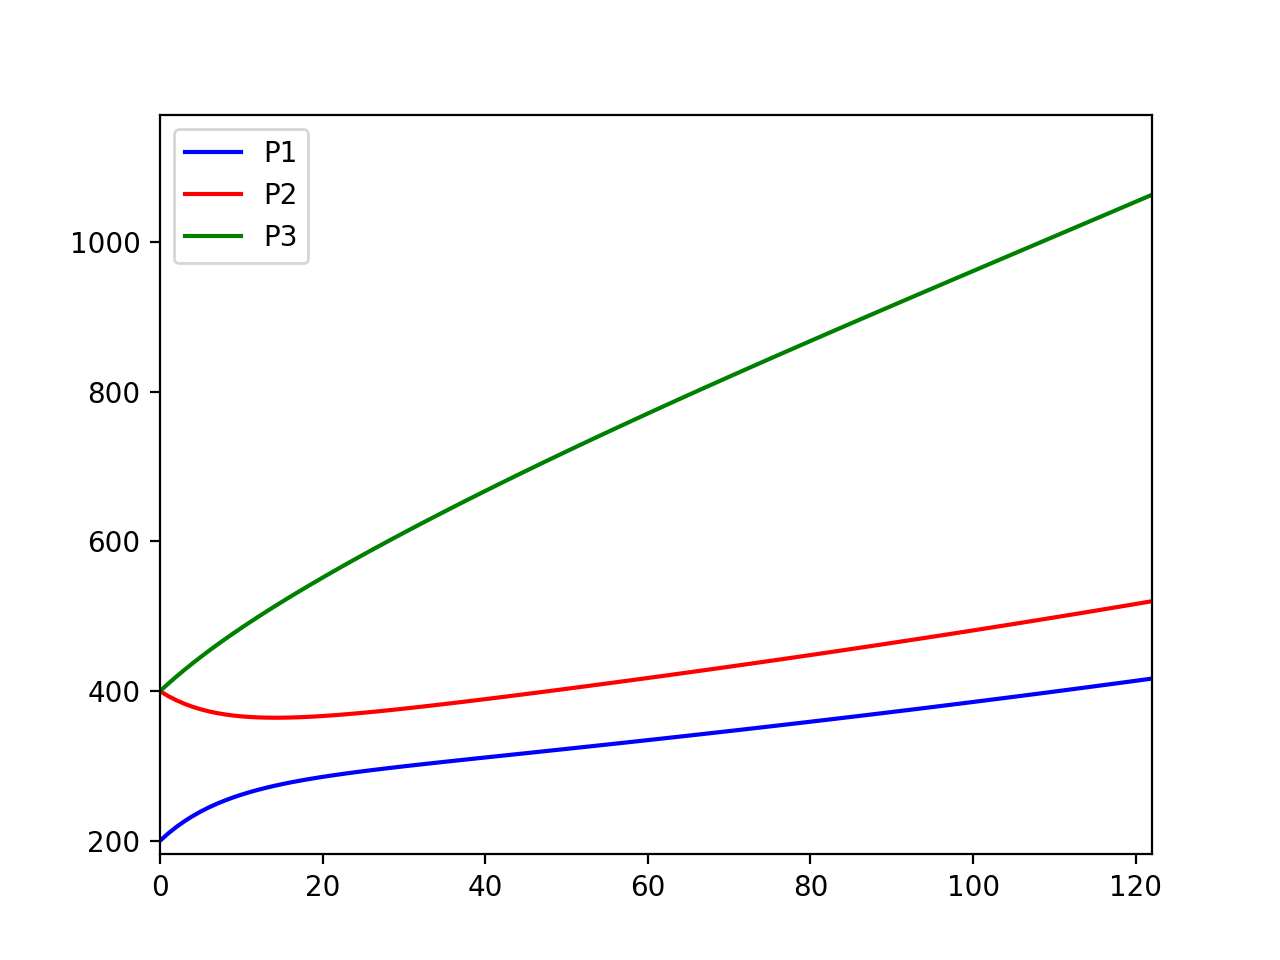

In [56]:
nit=122 # nit is no of time steps

#initialise list to zero

P1=[0]*(nit+1)
P2=[0]*(nit+1)
P3=[0]*(nit+1)

#Given initial population

P1[0],P2[0],P3[0]=P0[0], P0[1], P0[2]

# compute P1,P2,P3 
for n in range(1,nit+1):
    AP=np.matmul(A,[P1[n-1],P2[n-1],P3[n-1]]) # AP[n-1]
    P1[n],P2[n],P3[n]=AP[0,0],AP[0,1],AP[0,2]

# plotting 

t=np.arange(0,nit+1,1) #  time steps
plt.figure()
P1plot,=plt.plot(t,P1,'b-')
P2plot,=plt.plot(t,P2,'r-')
P3plot,=plt.plot(t,P3,'g-')
plt.legend((P1plot,P2plot,P3plot),('P1','P2','P3'))
Pmax=max(max(P1),max(P2),max(P3))
Pmin=min(min(P1),min(P1),min(P1))
plt.axis([0,nit,Pmin/1.1,Pmax*1.1])
plt.show()

In [57]:
print(P2[122]/P1[122],u1[1,0]/u1[0,0]) # compare first and second cohorts to eigenvector entries

1.248049187924413 1.248049155293366


In [58]:
print(P3[122]/P1[122],u1[2,0]/u1[0,0]) # compare first and third cohorts to eigenvector entries

2.5512020932531168 2.664354161915348


**(c)**

**(ii) $𝑃_1=400, 𝑃_2=𝑃_3=300$**

In [62]:
P0=[400,300,300] 

totalPopulation = sum(P0)
print("Starting population: ",totalPopulation)

Starting population:  1000


In [63]:
years = 0
for n in range(300):
    An=np.linalg.matrix_power(A,n) # matrix A^n
    Pn=np.matmul(An,P0) # population after n years
    if Pn.sum() > totalPopulation*2:
        years = n
        break;
print("The total population doubles after ", n, " years.")


The total population doubles after  98  years.


<IPython.core.display.Javascript object>


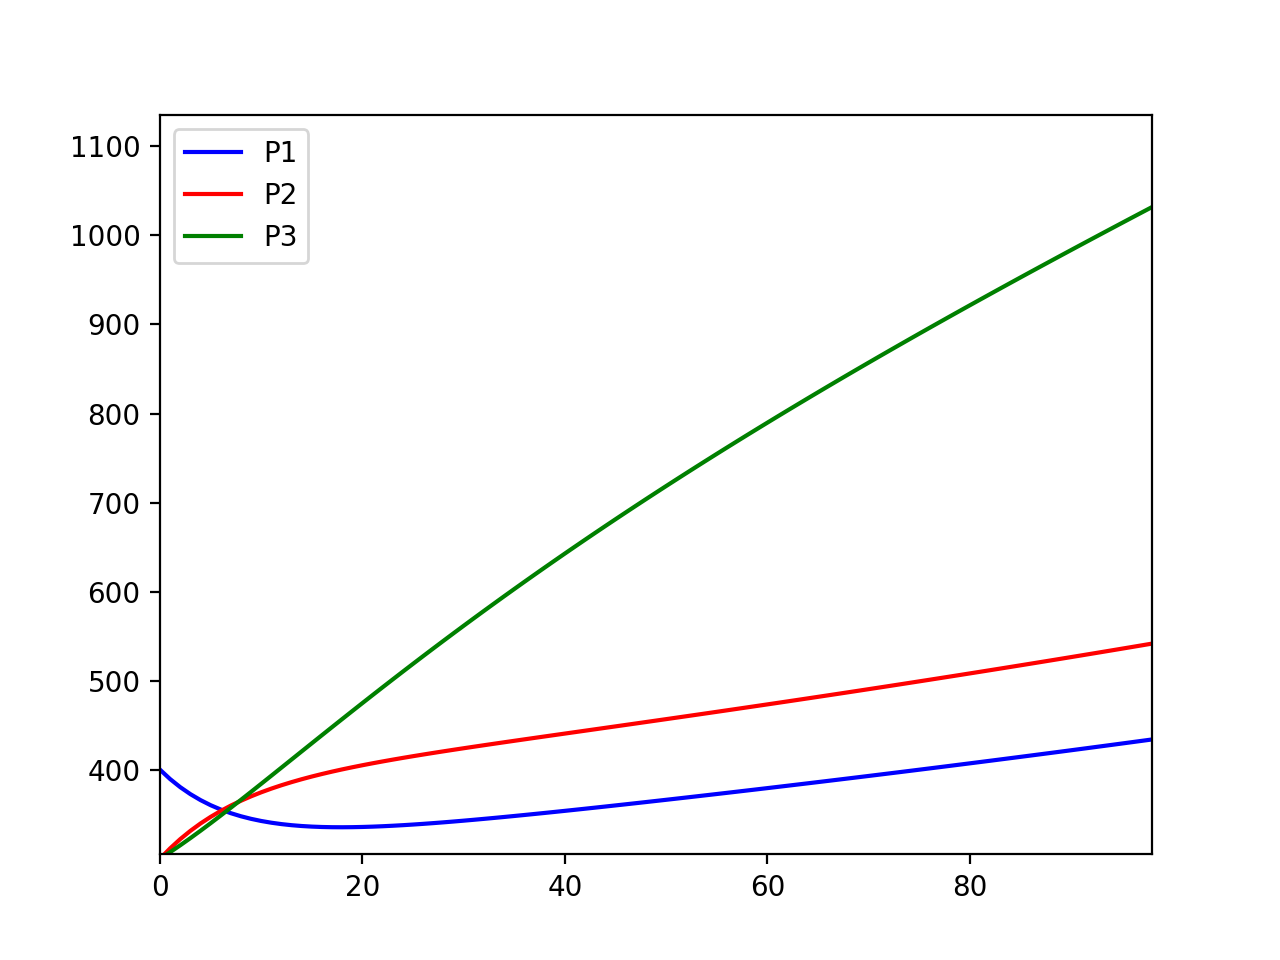

In [64]:
nit=98 # nit is no of time steps

#initialise list to zero

P1=[0]*(nit+1)
P2=[0]*(nit+1)
P3=[0]*(nit+1)

#Given initial population

P1[0],P2[0],P3[0]=P0[0], P0[1], P0[2]

# compute P1,P2,P3 
for n in range(1,nit+1):
    AP=np.matmul(A,[P1[n-1],P2[n-1],P3[n-1]]) # AP[n-1]
    P1[n],P2[n],P3[n]=AP[0,0],AP[0,1],AP[0,2]

# plotting 

t=np.arange(0,nit+1,1) #  time steps
plt.figure()
P1plot,=plt.plot(t,P1,'b-')
P2plot,=plt.plot(t,P2,'r-')
P3plot,=plt.plot(t,P3,'g-')
plt.legend((P1plot,P2plot,P3plot),('P1','P2','P3'))
Pmax=max(max(P1),max(P2),max(P3))
Pmin=min(min(P1),min(P1),min(P1))
plt.axis([0,nit,Pmin/1.1,Pmax*1.1])
plt.show()

In [66]:
print(P2[98]/P1[98],u1[1,0]/u1[0,0]) # compare first and second cohorts to eigenvector entries

1.248048146439516 1.248049155293366


In [67]:
print(P3[98]/P1[98],u1[2,0]/u1[0,0]) # compare first and third cohorts to eigenvector entries

2.377783277474929 2.664354161915348


**(iii) $𝑃_1=200, 𝑃_2=500, 𝑃_3=300$**

In [69]:
P0=[200,500,300] 

totalPopulation = sum(P0)
print("Starting population: ",totalPopulation)

Starting population:  1000


In [70]:
years = 0
for n in range(300):
    An=np.linalg.matrix_power(A,n) # matrix A^n
    Pn=np.matmul(An,P0) # population after n years
    if Pn.sum() > totalPopulation*2:
        years = n
        break;
print("The total population doubles after ", n, " years.")


The total population doubles after  89  years.


<IPython.core.display.Javascript object>


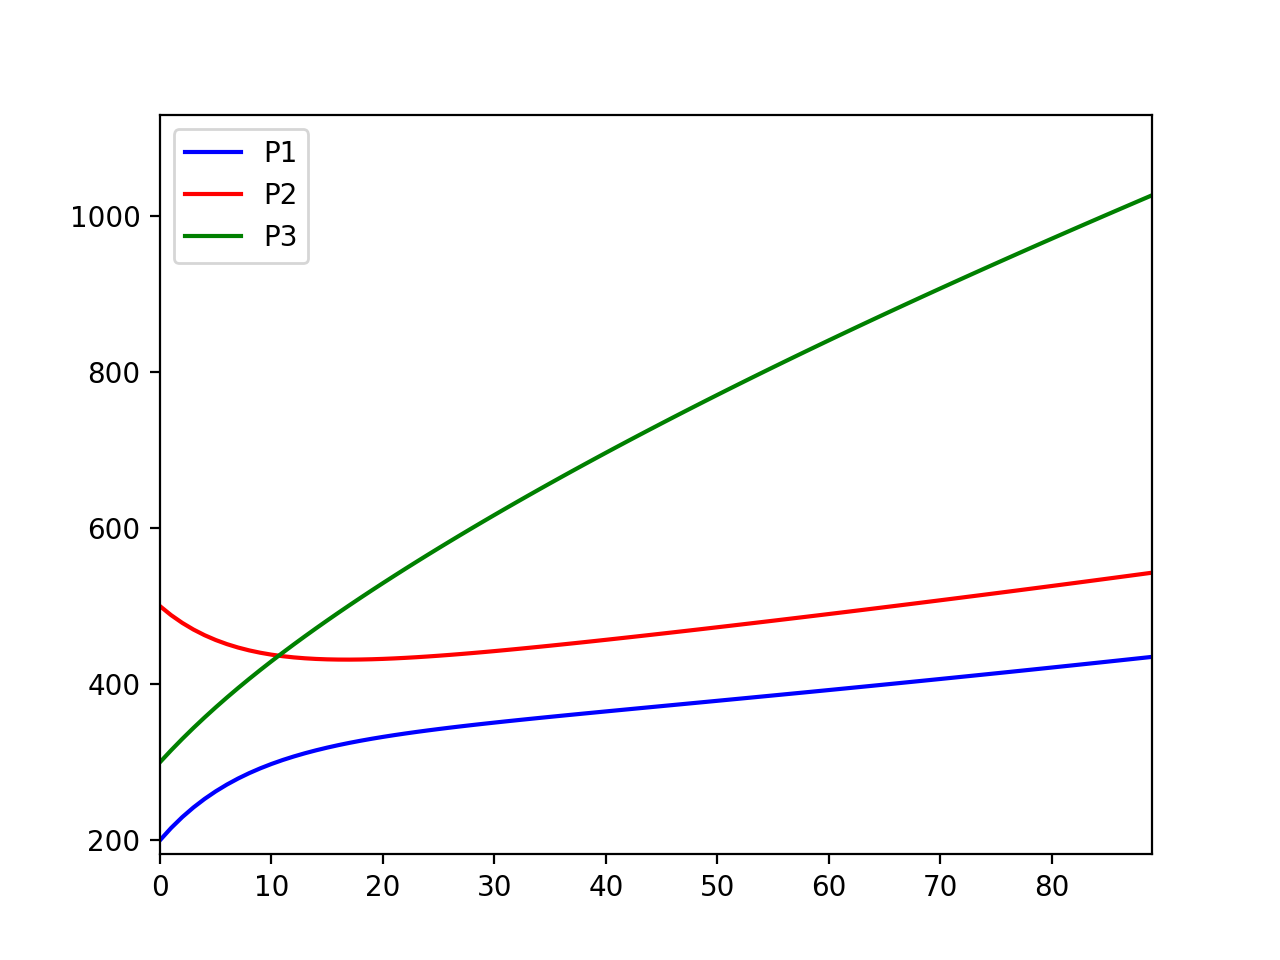

In [71]:
nit=89 # nit is no of time steps

#initialise list to zero

P1=[0]*(nit+1)
P2=[0]*(nit+1)
P3=[0]*(nit+1)

#Given initial population

P1[0],P2[0],P3[0]=P0[0], P0[1], P0[2]

# compute P1,P2,P3 
for n in range(1,nit+1):
    AP=np.matmul(A,[P1[n-1],P2[n-1],P3[n-1]]) # AP[n-1]
    P1[n],P2[n],P3[n]=AP[0,0],AP[0,1],AP[0,2]

# plotting 

t=np.arange(0,nit+1,1) #  time steps
plt.figure()
P1plot,=plt.plot(t,P1,'b-')
P2plot,=plt.plot(t,P2,'r-')
P3plot,=plt.plot(t,P3,'g-')
plt.legend((P1plot,P2plot,P3plot),('P1','P2','P3'))
Pmax=max(max(P1),max(P2),max(P3))
Pmin=min(min(P1),min(P1),min(P1))
plt.axis([0,nit,Pmin/1.1,Pmax*1.1])
plt.show()

In [73]:
print(P2[89]/P1[89],u1[1,0]/u1[0,0]) # compare first and second cohorts to eigenvector entries

1.248053340193975 1.248049155293366


In [74]:
print(P3[89]/P1[89],u1[2,0]/u1[0,0]) # compare first and third cohorts to eigenvector entries

2.3601791730634036 2.664354161915348


We can see from the three different initial populations that regardless of initial population, over time P1, P2 and P3 grow exponentially, in line with the dominant eigenvalue of 1.004

## Q.4 (*) Chaotic Models 
Consider the Ricker model of Salmon population size as follows 

$$
P_{n+1}=re^{-\frac{P_{n}}{K}}P_{n} 
$$

where $r$ is the rate and $K$ is another parameter. For simplicity choose $K=500$ and consider the behaviour of this system for

(a). $r<1$, with initial population of $1000$.

(b). $1<r<e^{2}$, for initial population 100, 500 and 1000.

(c). $r>e^{2}$, for initial population 100, 500 and 1000.

Explain what you see.

<IPython.core.display.Javascript object>


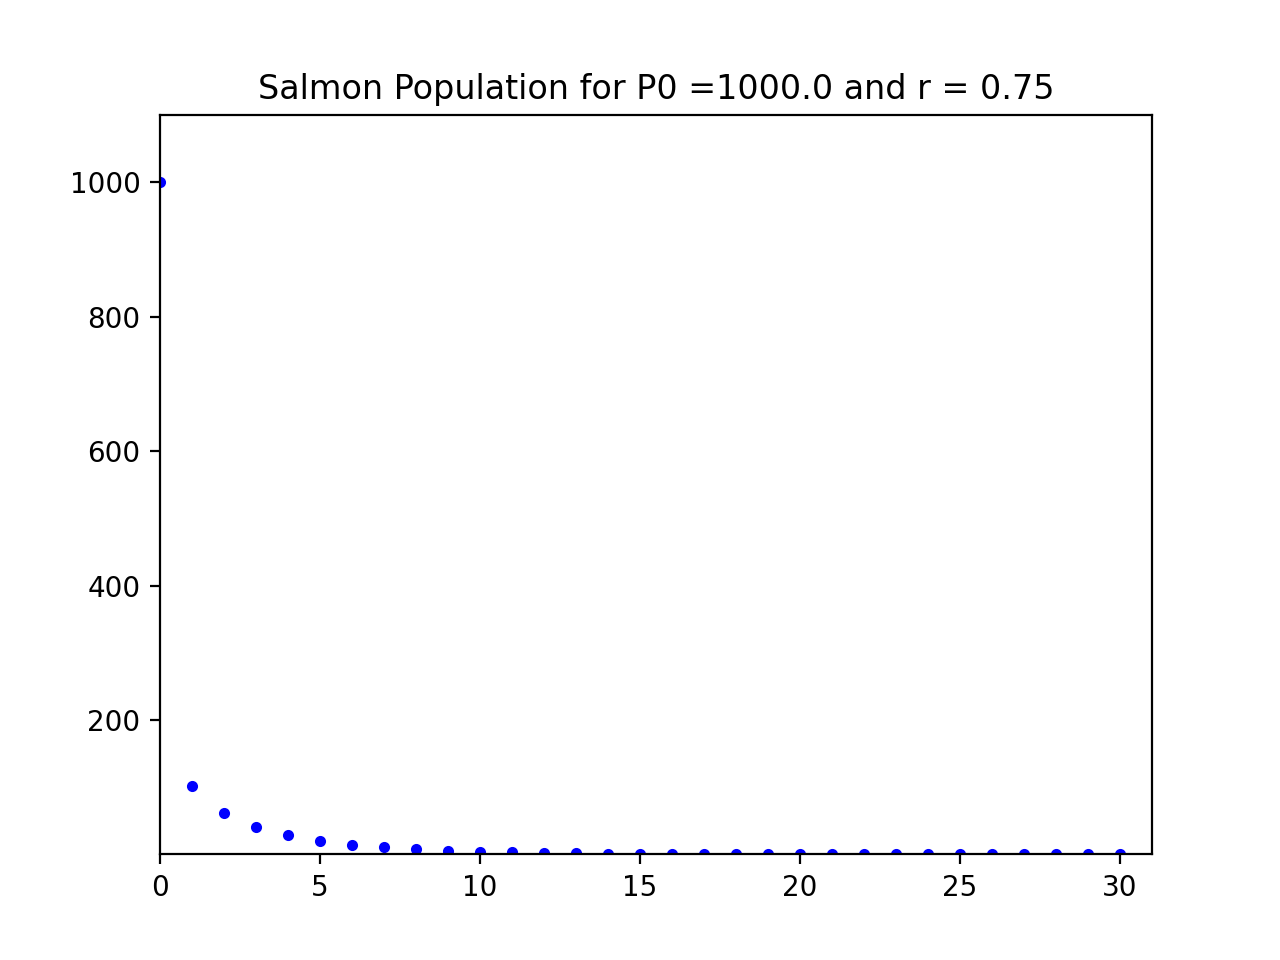

In [75]:
# initial values
P_0=1000.
K=500.
r=0.75

nit=30 # nit is no of time steps

t=np.arange(0,nit+1,1) #  time steps

P=[0]*(nit+1) # list for P initialized with nit zeros

P[0]=P_0 # given initial population
for n in range(1,nit+1):
    P[n]=r*P[n-1]*np.exp(-P[n-1]/K) 

# plotting 
plt.figure()
plt.plot(t,P,'b.')
Pmax=max(P)
Pmin=min(P)
plt.axis([0,nit+1,Pmin/1.1,Pmax*1.1])
plt.title('Salmon Population for P0 =' +str(P_0)+ ' and r = ' +str(r))
plt.show()

Population dies out for $r<1$. 

Explore the other values of $r$ where one can find convergence to non-zero population for $1<r<e^{2}$ and period doubling phenomena and chaos for $r>e^{2}$.

In [76]:
e2=np.exp(2)
print(e2)

7.38905609893065


(b). $1<r<e^{2}$, for initial population 100, 500 and 1000.

<IPython.core.display.Javascript object>


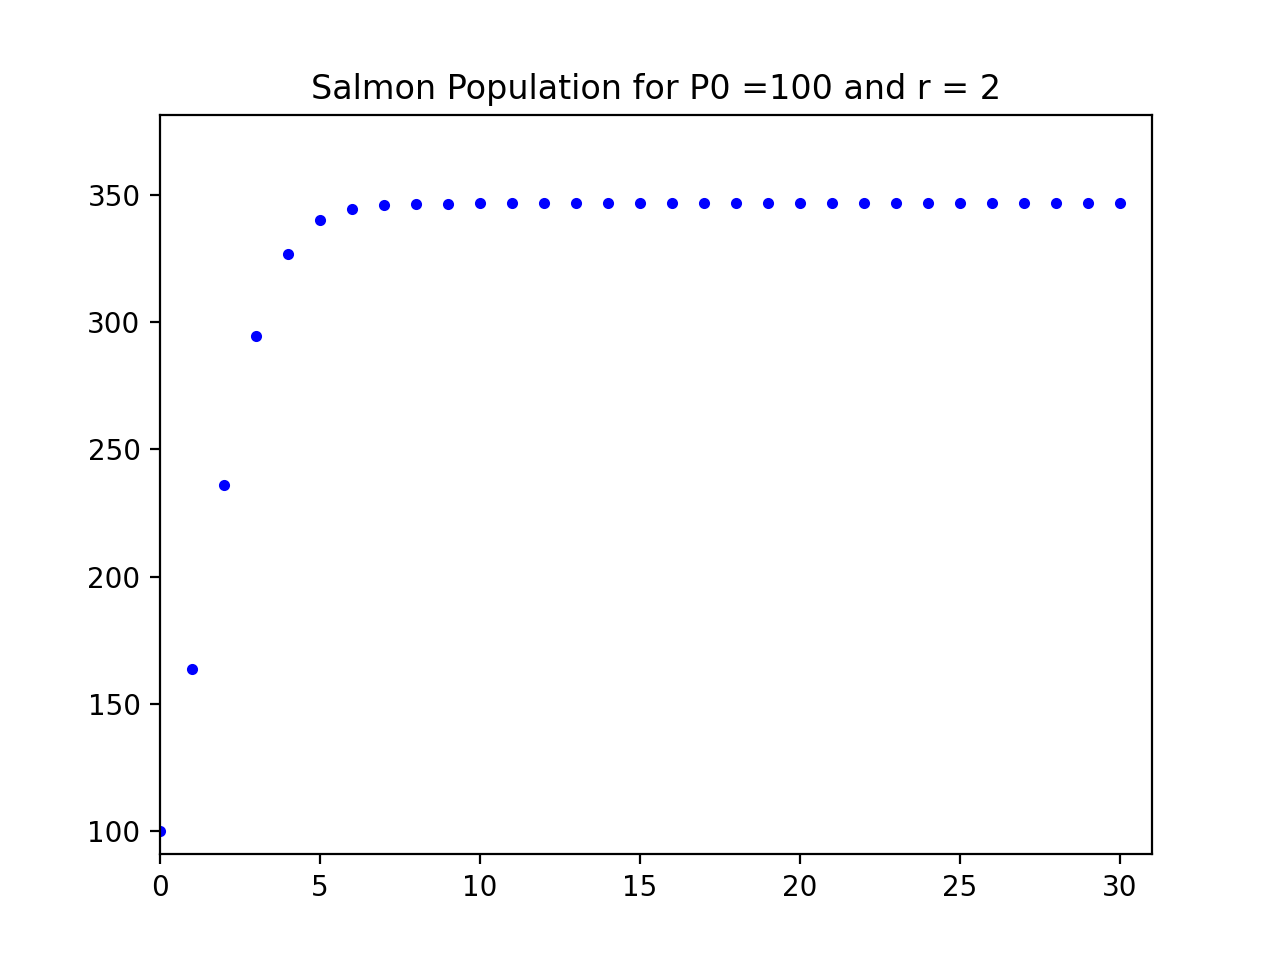

<IPython.core.display.Javascript object>


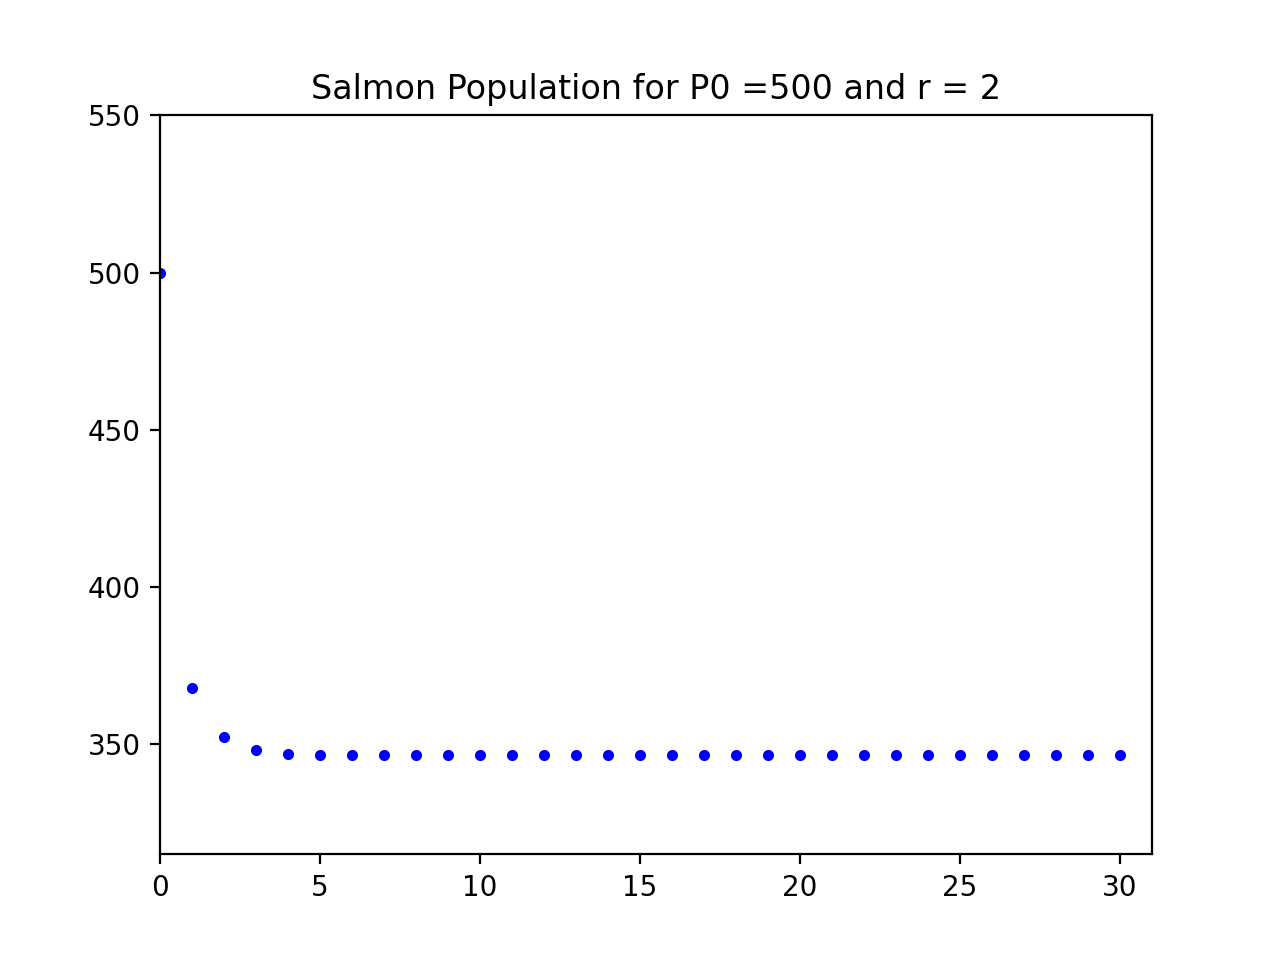

<IPython.core.display.Javascript object>


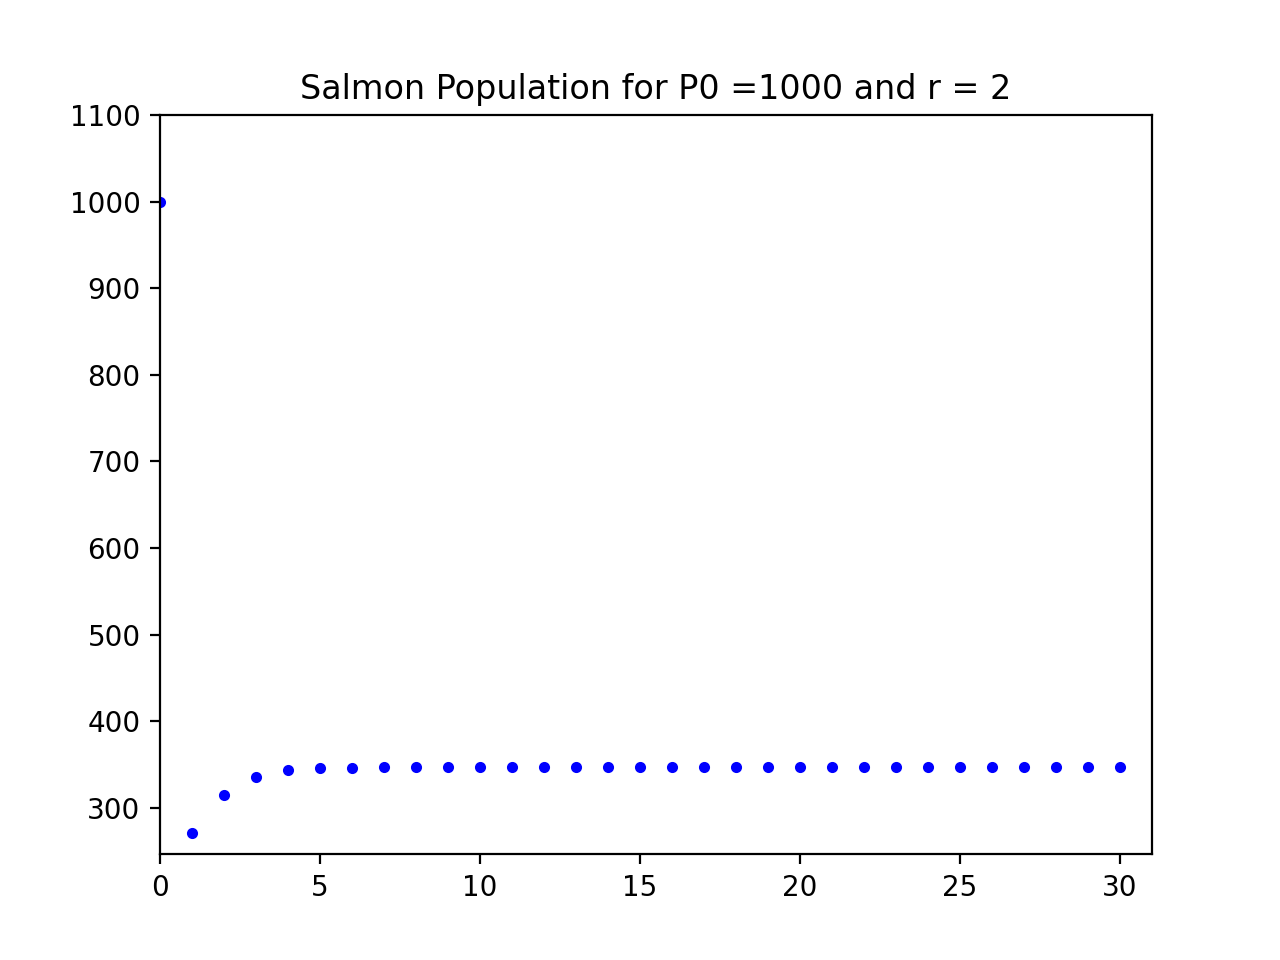

In [103]:
#r = 2
populations = [100, 500, 1000]
for i in range(3):
    # initial values
    P_0=populations[i]
    K=500
    r=2

    nit=30 # nit is no of time steps

    t=np.arange(0,nit+1,1) #  time steps

    P=[0]*(nit+1) # list for P initialized with nit zeros

    P[0]=P_0 # given initial population
    for n in range(1,nit+1):
        P[n]=r*P[n-1]*np.exp(-P[n-1]/K) 

    # plotting 
    plt.figure()
    plt.plot(t,P,'b.')
    Pmax=max(P)
    Pmin=min(P)
    plt.axis([0,nit+1,Pmin/1.1,Pmax*1.1])
    plt.title('Salmon Population for P0 =' +str(P_0)+ ' and r = ' +str(r))
    plt.show()

When $R_0$ = 2, the population converges to $P^* = K\ln{R_0} = (500)(\ln{2})= 346.57$ 

<IPython.core.display.Javascript object>


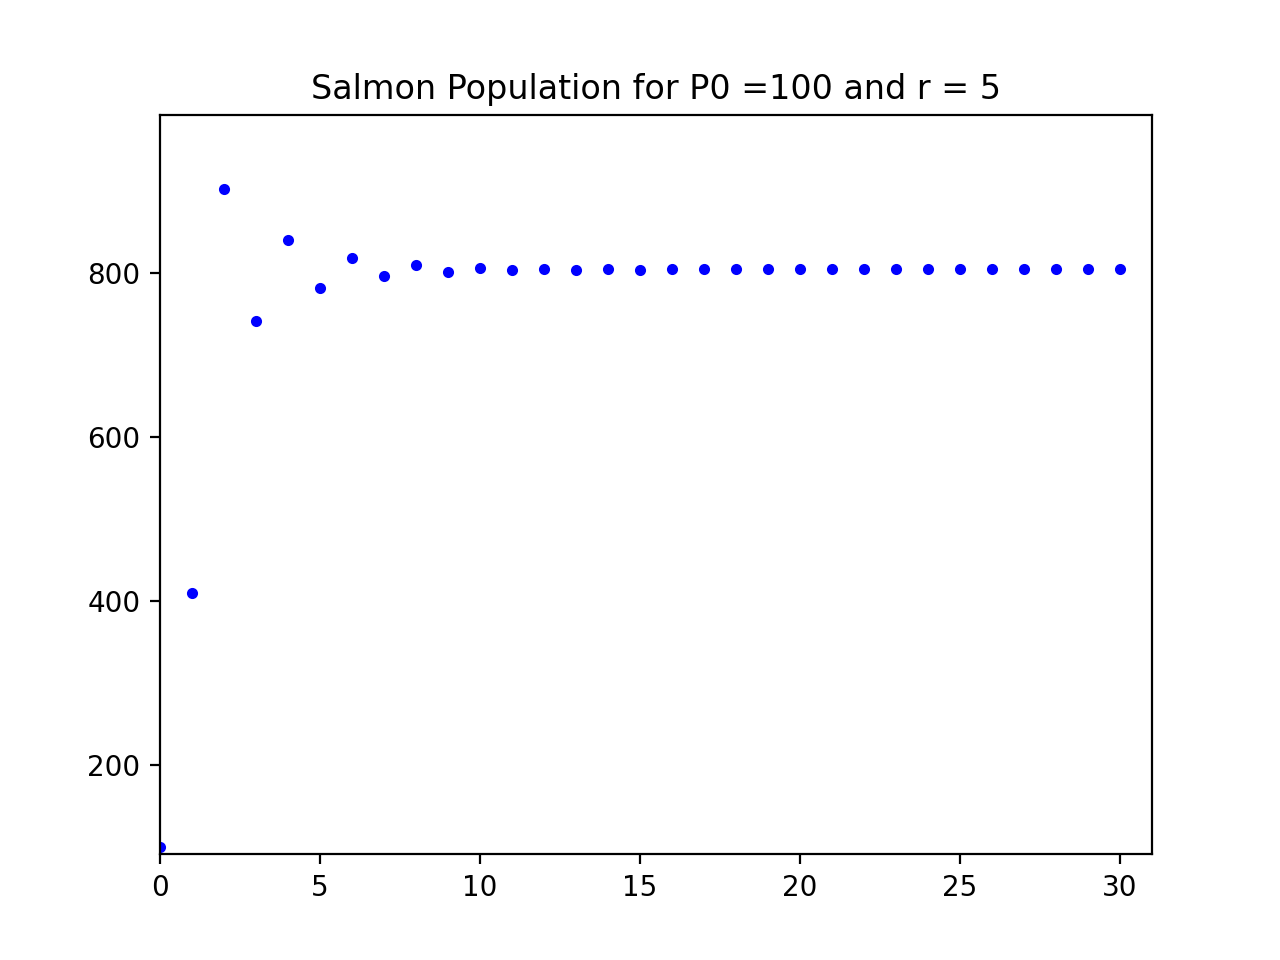

<IPython.core.display.Javascript object>


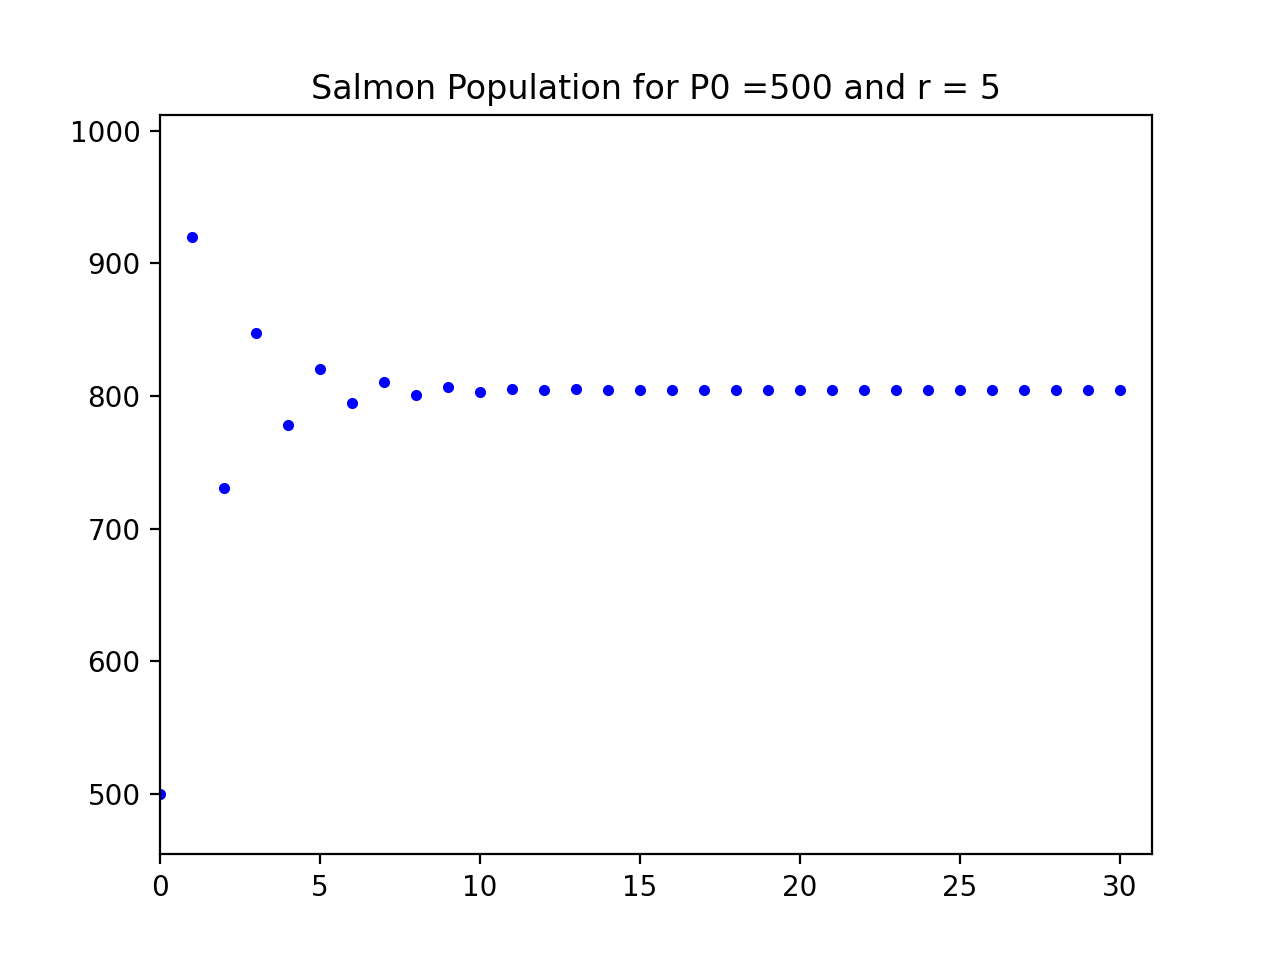

<IPython.core.display.Javascript object>


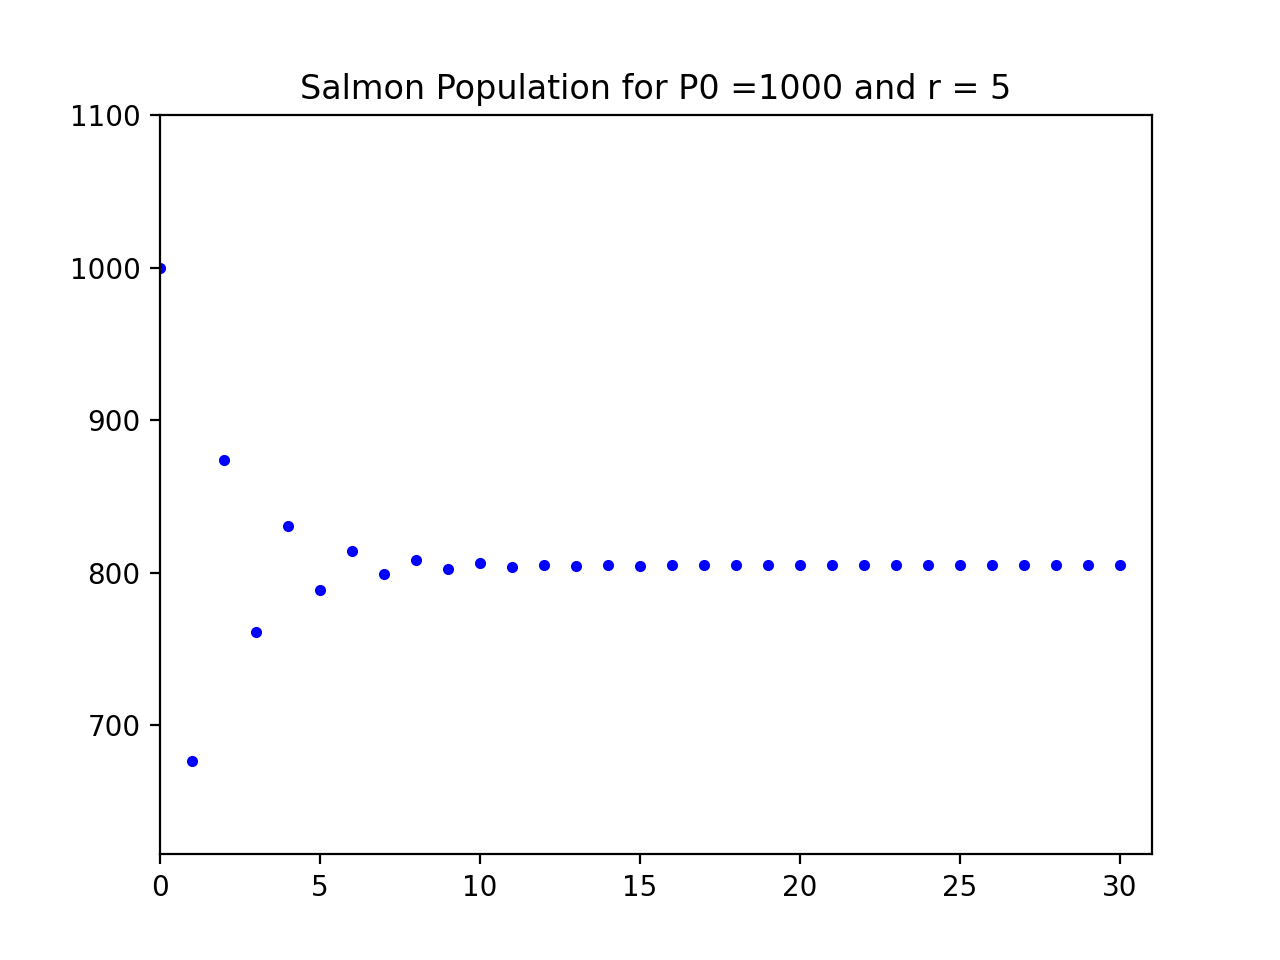

In [108]:
#r = 5
populations = [100, 500, 1000]
for i in range(3):
    # initial values
    P_0=populations[i]
    K=500
    r=5

    nit=30 # nit is no of time steps

    t=np.arange(0,nit+1,1) #  time steps

    P=[0]*(nit+1) # list for P initialized with nit zeros

    P[0]=P_0 # given initial population
    for n in range(1,nit+1):
        P[n]=r*P[n-1]*np.exp(-P[n-1]/K) 

    # plotting 
    plt.figure()
    plt.plot(t,P,'b.')
    Pmax=max(P)
    Pmin=min(P)
    plt.axis([0,nit+1,Pmin/1.1,Pmax*1.1])
    plt.title('Salmon Population for P0 =' +str(P_0)+ ' and r = ' +str(r))
    plt.show()    

When $R_0$ = 5, the population converges to $P^* = K\ln{R_0} = (500)(\ln{5})= 804.72$

(c). $r>e^{2}$, for initial population 100, 500 and 1000.

<IPython.core.display.Javascript object>


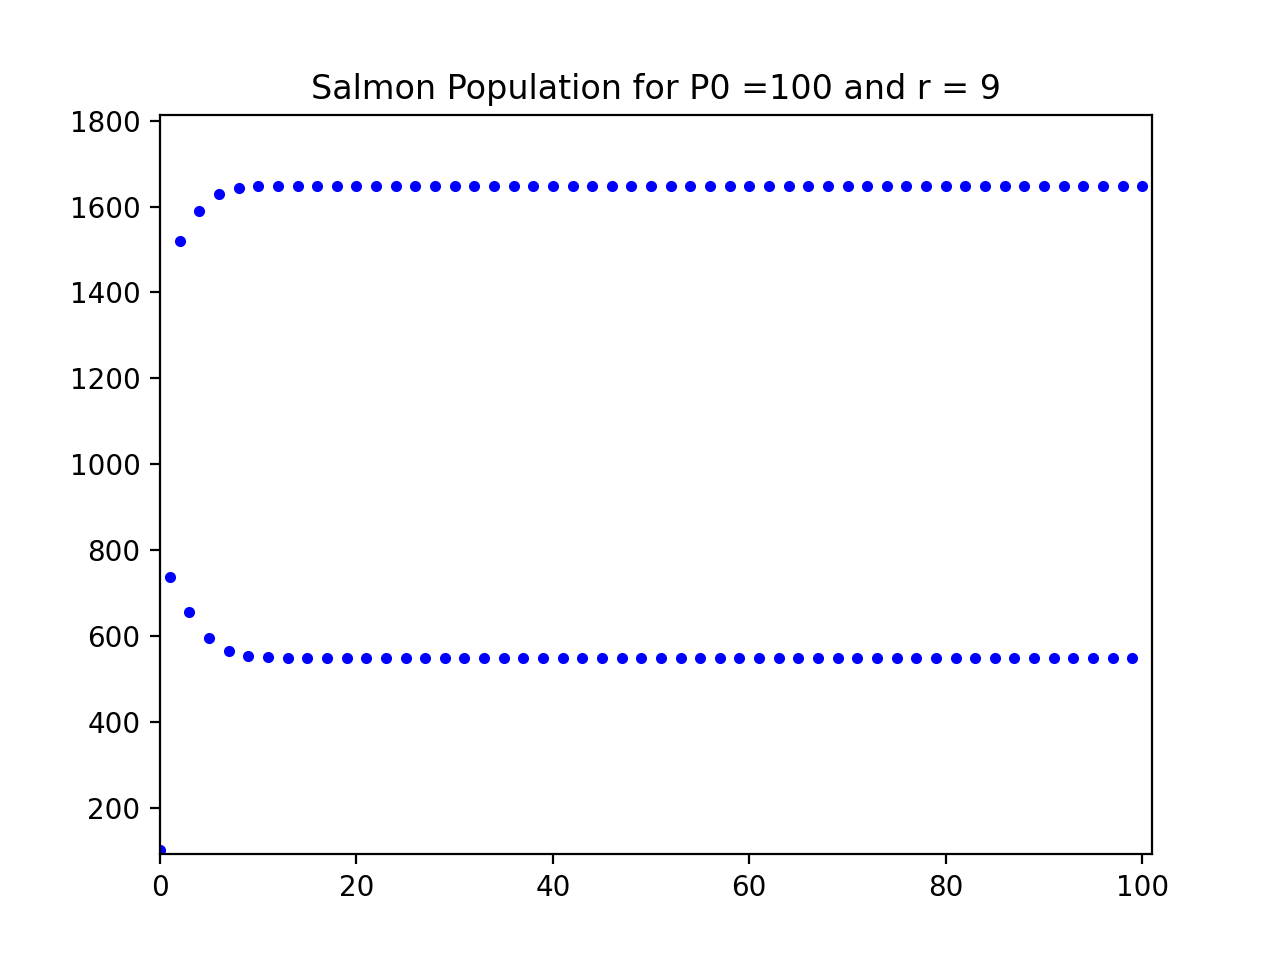

<IPython.core.display.Javascript object>


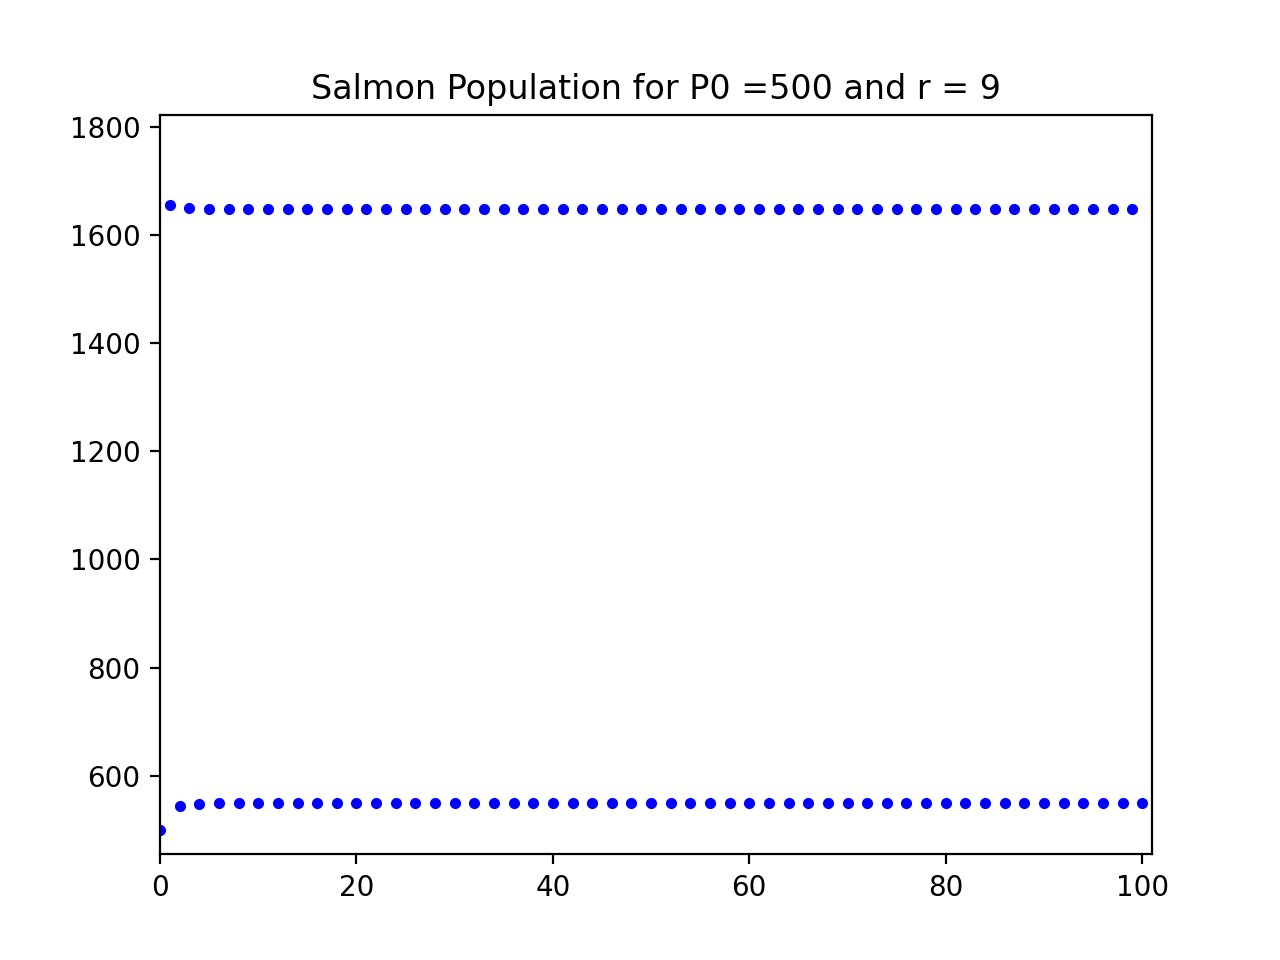

<IPython.core.display.Javascript object>


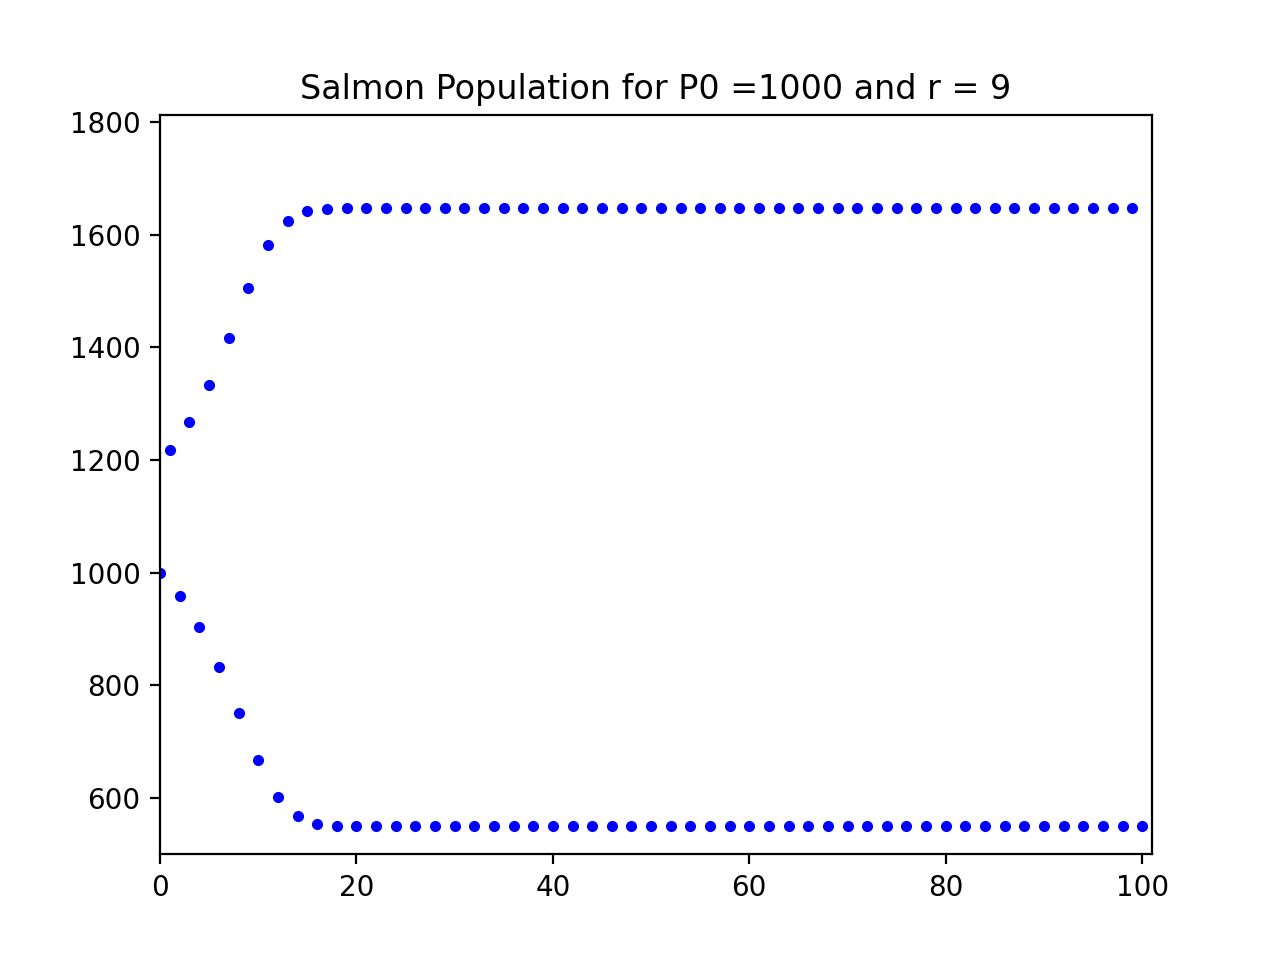

In [112]:
#r = 9
populations = [100, 500, 1000]
for i in range(3):
    # initial values
    P_0=populations[i]
    K=500
    r=9
    
    
    nit=100 # nit is no of time steps

    t=np.arange(0,nit+1,1) #  time steps

    P=[0]*(nit+1) # list for P initialized with nit zeros

    P[0]=P_0 # given initial population
    for n in range(1,nit+1):
        P[n]=r*P[n-1]*np.exp(-P[n-1]/K)
        

    # plotting 
    plt.figure()
    plt.plot(t,P,'b.')
    Pmax=max(P)
    Pmin=min(P)
    plt.axis([0,nit+1,Pmin/1.1,Pmax*1.1])
    plt.title('Salmon Population for P0 =' +str(P_0)+ ' and r = ' +str(r))
    plt.show()

When $R_0$ = 9 we see that period doubling occurs with $1647.92 \approx F(549.31)$ and $549.31 \approx F(1647.92)$ where the population stabilises at either 1648 or 549 depending on the previous year.

<IPython.core.display.Javascript object>


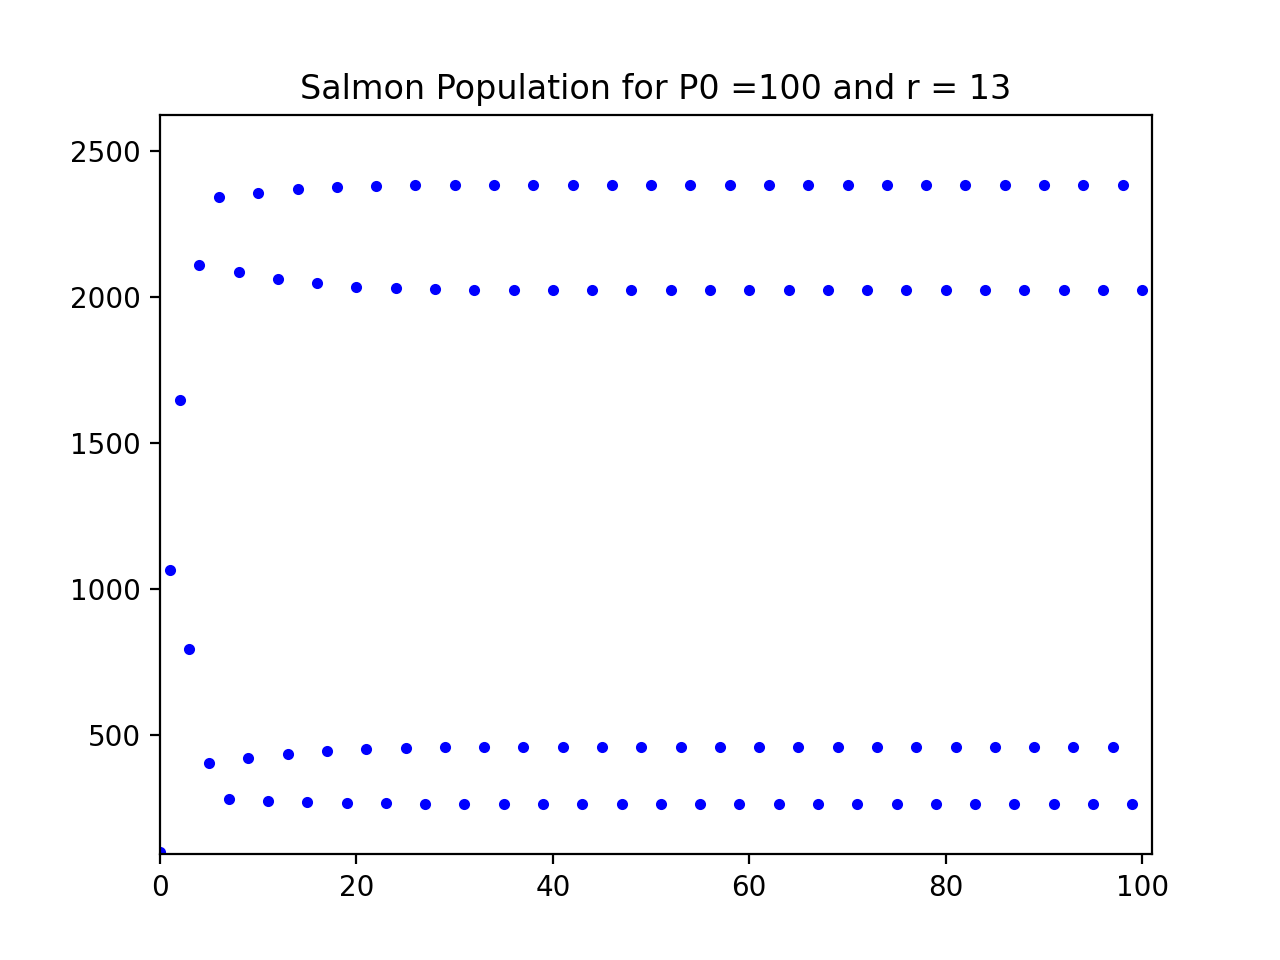

<IPython.core.display.Javascript object>


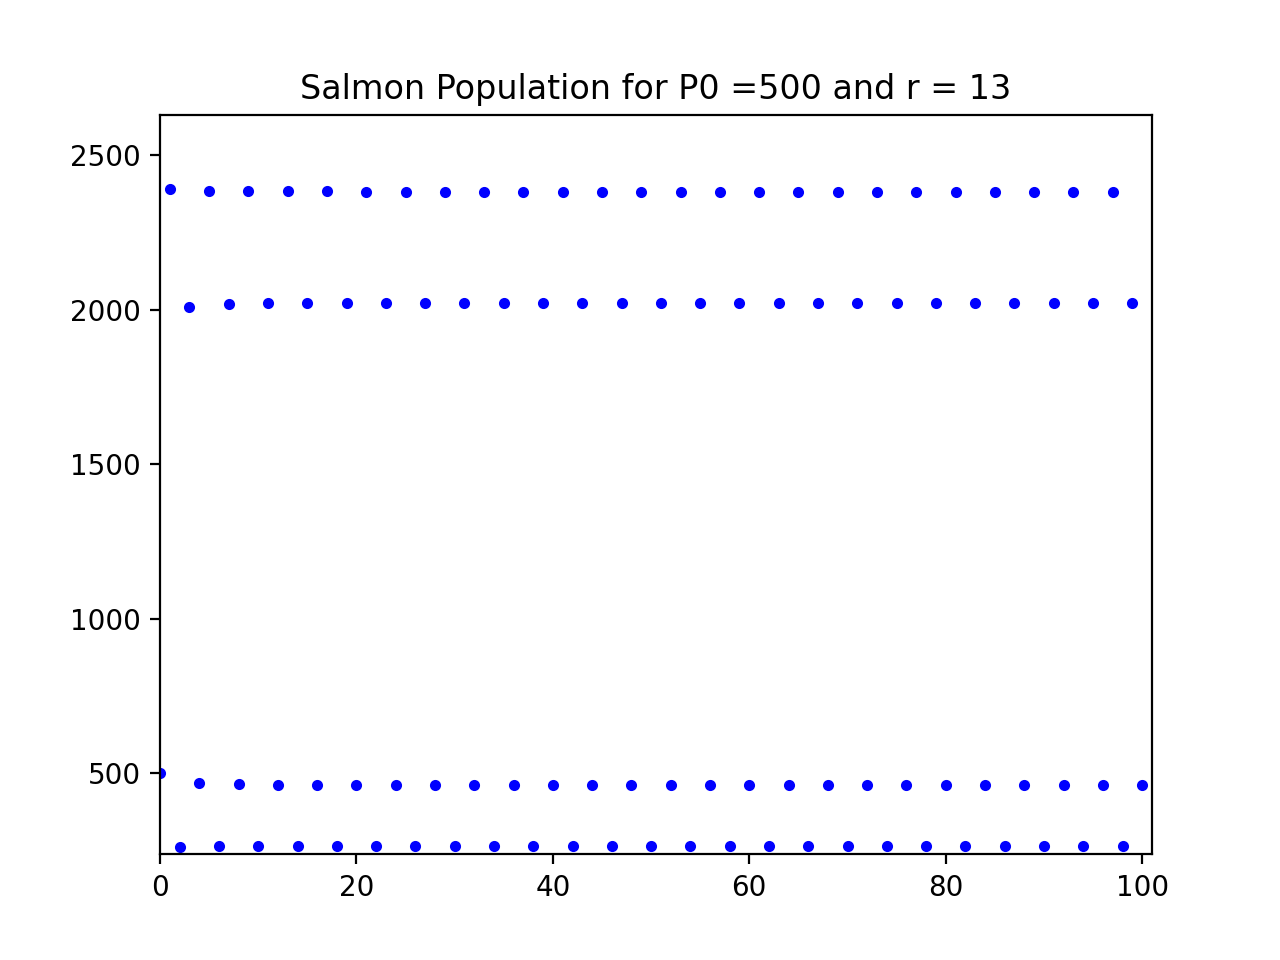

<IPython.core.display.Javascript object>


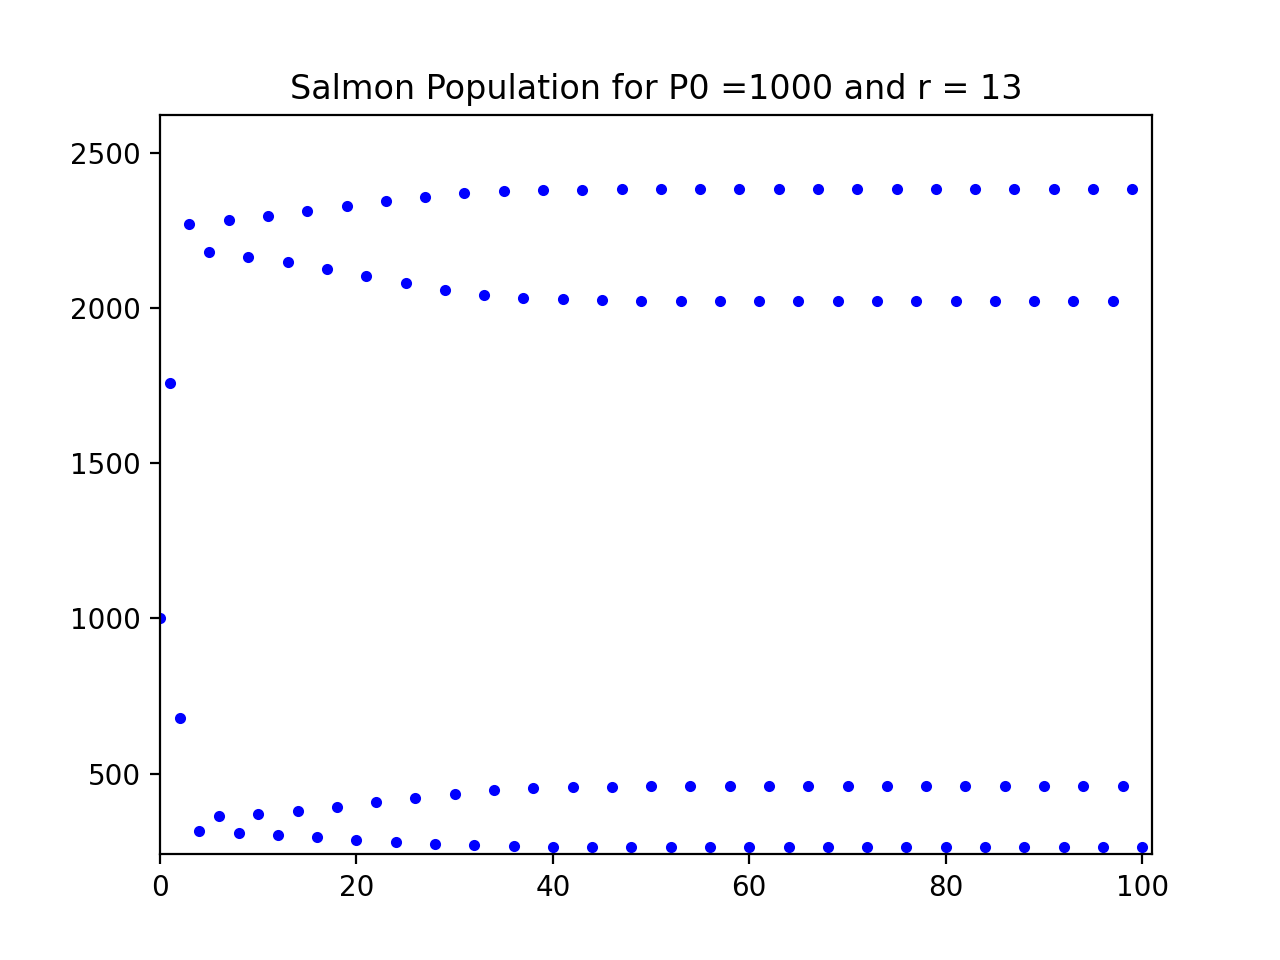

In [116]:
#r = 13
populations = [100, 500, 1000]
for i in range(3):
    # initial values
    P_0=populations[i]
    K=500
    r=13
    
    
    nit=100 # nit is no of time steps

    t=np.arange(0,nit+1,1) #  time steps

    P=[0]*(nit+1) # list for P initialized with nit zeros

    P[0]=P_0 # given initial population
    for n in range(1,nit+1):
        P[n]=r*P[n-1]*np.exp(-P[n-1]/K)
        

    # plotting 
    plt.figure()
    plt.plot(t,P,'b.')
    Pmax=max(P)
    Pmin=min(P)
    plt.axis([0,nit+1,Pmin/1.1,Pmax*1.1])
    plt.title('Salmon Population for P0 =' +str(P_0)+ ' and r = ' +str(r))
    plt.show()

When $R_0$ = 13 we see further period doubling occuring.

<IPython.core.display.Javascript object>


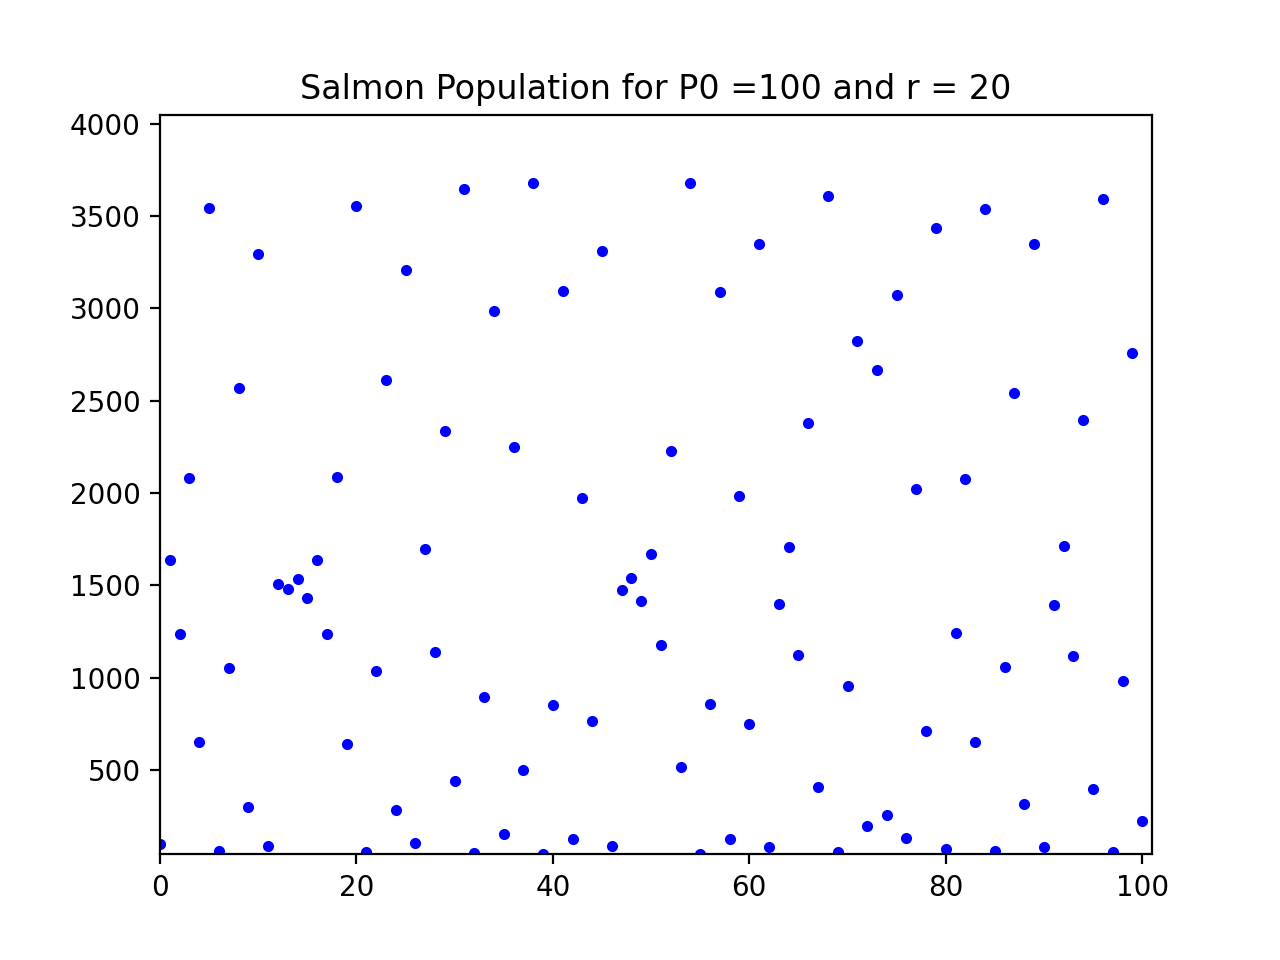

<IPython.core.display.Javascript object>


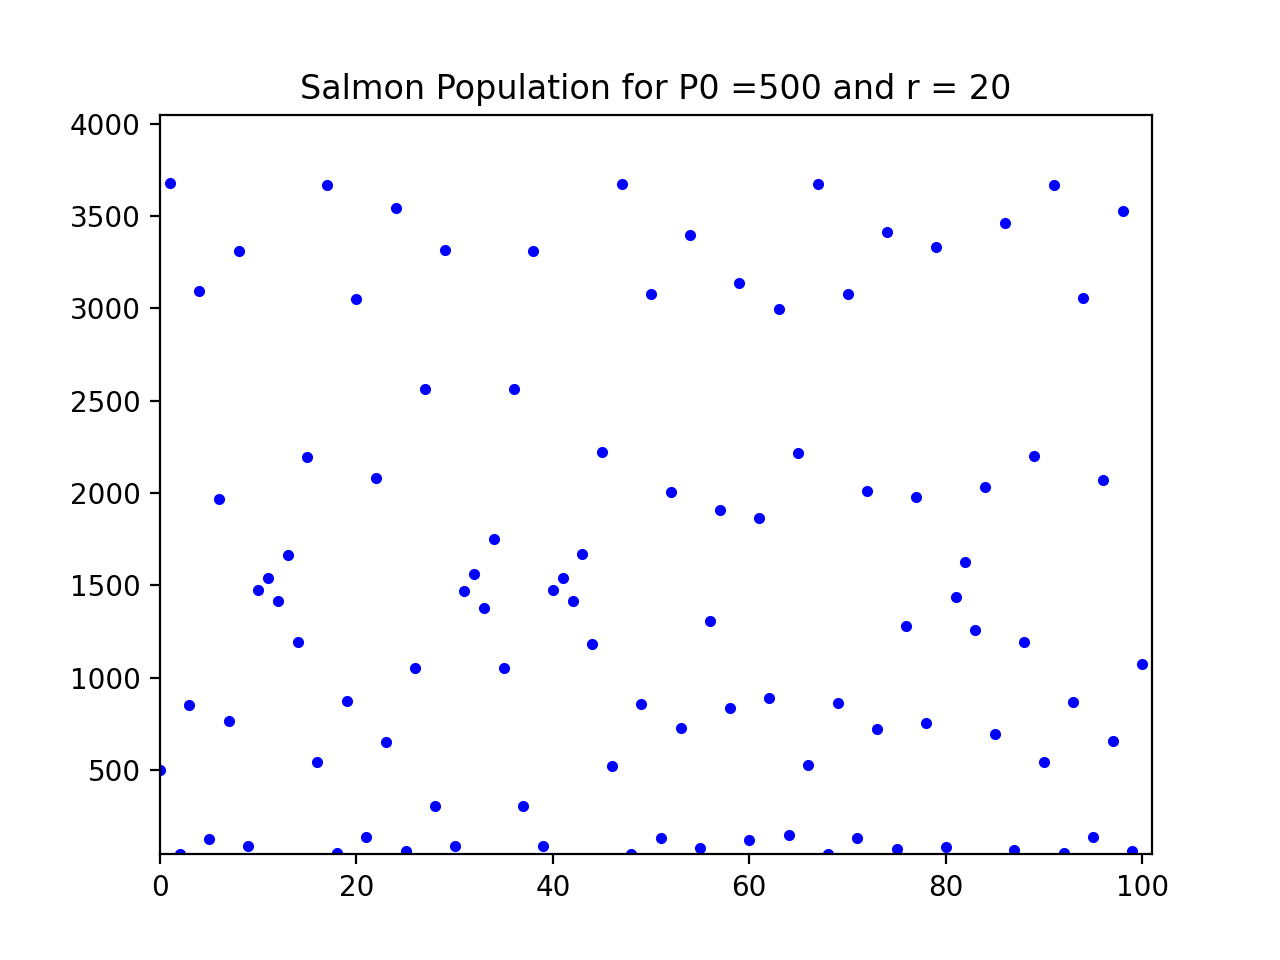

<IPython.core.display.Javascript object>


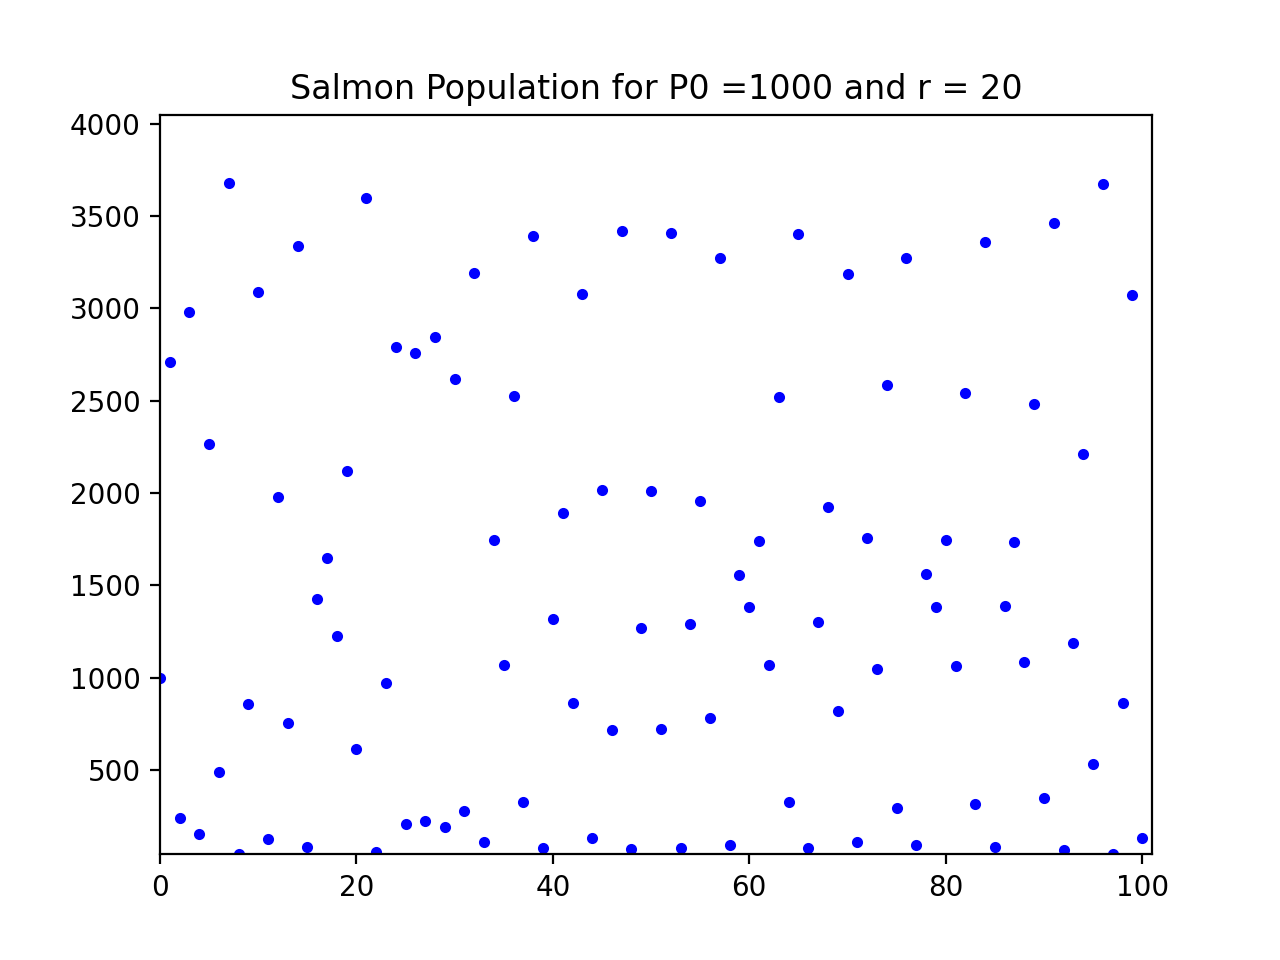

In [102]:
#r = 20
populations = [100, 500, 1000]
for i in range(3):
    # initial values
    P_0=populations[i]
    K=500
    r=20

    nit=100 # nit is no of time steps

    t=np.arange(0,nit+1,1) #  time steps

    P=[0]*(nit+1) # list for P initialized with nit zeros

    P[0]=P_0 # given initial population
    for n in range(1,nit+1):
        P[n]=r*P[n-1]*np.exp(-P[n-1]/K) 

    # plotting 
    plt.figure()
    plt.plot(t,P,'b.')
    Pmax=max(P)
    Pmin=min(P)
    plt.axis([0,nit+1,Pmin/1.1,Pmax*1.1])
    plt.title('Salmon Population for P0 =' +str(P_0)+ ' and r = ' +str(r))
    plt.show()

When $R_0$ = 20 we see unpredictable chaotic behaviour.